<a href="https://www.kaggle.com/code/ashrafulalam13/forgedreal-sign-detection?scriptVersionId=355388846" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ashrafulalam13/eegemgsigndetection/EEG_EMG_Dataset.xlsx


In [2]:
!pip install imbalanced-learn openpyxl --quiet

In [3]:
# =============================================================================
# 1.  IMPORTS & SEEDS
# =============================================================================
import os, warnings, math, random
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
 
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
 
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
 
print("TensorFlow version :", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs available      :", gpus)
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
 

2026-10-05 08:10:10.341632: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791187810.575268      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791187810.632164      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791187811.200548      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791187811.200594      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791187811.200597      23 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPUs available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
# =============================================================================
# 2.  LOAD DATA
# =============================================================================
# ── Adjust this path to match your Kaggle dataset location ───────────────────
DATA_PATH = "/kaggle/input/datasets/ashrafulalam13/eegemgsigndetection/EEG_EMG_Dataset.xlsx"
# Local fallback:
# DATA_PATH = "EEG_EMG_Dataset.xlsx"
 
df = pd.read_excel(DATA_PATH, sheet_name="EEG_EMG_Data")
 
feature_cols = [c for c in df.columns if c.startswith("Feature_")]
label_col    = "Label"
 
X_all = df[feature_cols].values.astype(np.float32)   # (160, 309)
y_all = df[label_col].values.astype(np.int32)         # (160,)
 
N_SUBJECTS    = 16
ROWS_PER_SUB  = 10          # 5 Forged + 5 Real
N_FEATURES    = X_all.shape[1]   # 309
 
print(f"\nFull dataset : {X_all.shape}")
print(f"Label counts : Forged={( y_all==0).sum()}  Real={(y_all==1).sum()}")
 
# Assign subject IDs  (0-based)
subject_ids = np.repeat(np.arange(N_SUBJECTS), ROWS_PER_SUB)
 
# =============================================================================
# 3.  SUBJECT-WISE  70 / 30  SPLIT
#     Train : subjects  0-10  (11 subjects, 110 rows)
#     Test  : subjects 11-15  ( 5 subjects,  50 rows)  ← never touched until §9
# =============================================================================
TRAIN_SUBS = list(range(11))
TEST_SUBS  = list(range(11, 16))
 
train_mask = np.isin(subject_ids, TRAIN_SUBS)
test_mask  = np.isin(subject_ids, TEST_SUBS)
 
X_train_raw = X_all[train_mask]         # (110, 309)
y_train_raw = y_all[train_mask]
s_train     = subject_ids[train_mask]
 
X_test_raw  = X_all[test_mask]          # ( 50, 309)
y_test_raw  = y_all[test_mask]
s_test      = subject_ids[test_mask]
 
print(f"\nTrain (raw) : {X_train_raw.shape}  {np.bincount(y_train_raw)}")
print(f"Test  (raw) : {X_test_raw.shape}   {np.bincount(y_test_raw)}")
 
# =============================================================================
# 4.  SUBJECT-WISE AUGMENTATION  (training set ONLY)
#     Each of the 11 training subjects is augmented in isolation so that
#     no subject's biosignal characteristics bleed into another subject.
#
#     Per subject:
#       (a) Gaussian noise copies   – σ = 0.8 % of within-subject feature std
#       (b) Intra-class linear interpolation  – α ∈ [0.2, 0.8]
#     Then globally:
#       (c) SMOTE  (k=5) for class balance
#     Extra passes if pool < 1500 samples.
# =============================================================================
def augment_subject(X_sub, y_sub, sub_id,
                    n_noise=8, n_interp=12, noise_scale=0.008):
    """
    Augment one subject's 10 rows without touching other subjects.
    Returns stacked (X_aug, y_aug) including originals.
    """
    rng  = np.random.RandomState(sub_id * 137 + SEED)
    stds = X_sub.std(axis=0) + 1e-8
 
    X_out, y_out = [X_sub.copy()], [y_sub.copy()]
 
    # (a) Gaussian noise
    for _ in range(n_noise):
        X_out.append(X_sub + rng.randn(*X_sub.shape) * (noise_scale * stds))
        y_out.append(y_sub.copy())
 
    # (b) Intra-class interpolation
    for cls in [0, 1]:
        idx = np.where(y_sub == cls)[0]
        if len(idx) < 2:
            continue
        for _ in range(n_interp):
            i, j  = rng.choice(idx, 2, replace=False)
            alpha  = rng.uniform(0.2, 0.8)
            X_out.append((alpha * X_sub[i] + (1 - alpha) * X_sub[j])[None])
            y_out.append(np.array([cls]))
 
    return np.vstack(X_out), np.concatenate(y_out)
 
 
X_aug_parts, y_aug_parts = [], []
for sub_id in TRAIN_SUBS:
    mask = s_train == sub_id
    Xa, ya = augment_subject(X_train_raw[mask], y_train_raw[mask], sub_id)
    X_aug_parts.append(Xa)
    y_aug_parts.append(ya)
 
X_aug = np.vstack(X_aug_parts).astype(np.float32)
y_aug = np.concatenate(y_aug_parts).astype(np.int32)
print(f"\nAfter per-subject augmentation : {X_aug.shape}  {np.bincount(y_aug)}")
 
# (c) SMOTE
smote     = SMOTE(k_neighbors=5, random_state=SEED)
X_sm, y_sm = smote.fit_resample(X_aug, y_aug)
print(f"After SMOTE                    : {X_sm.shape}  {np.bincount(y_sm)}")
 
# Extra noise passes until ≥ 1500 samples
while len(X_sm) < 1500:
    idx     = np.random.choice(len(X_sm), 200, replace=True)
    X_extra = X_sm[idx] + np.random.randn(200, N_FEATURES).astype(np.float32) * 5e-3
    X_sm    = np.vstack([X_sm, X_extra]).astype(np.float32)
    y_sm    = np.concatenate([y_sm, y_sm[idx]]).astype(np.int32)
 
print(f"Final training pool            : {X_sm.shape}  {np.bincount(y_sm)}")
 


Full dataset : (160, 309)
Label counts : Forged=80  Real=80

Train (raw) : (110, 309)  [55 55]
Test  (raw) : (50, 309)   [25 25]

After per-subject augmentation : (1254, 309)  [627 627]
After SMOTE                    : (1254, 309)  [627 627]
Final training pool            : (1654, 309)  [826 828]


In [5]:
# =============================================================================
# 5.  PREPROCESSING  (fit on train → transform train & test)
#     Step 1 : Near-zero-variance (NZV) filter
#     Step 2 : Correlation filter  |r| > 0.95
#     Step 3 : RobustScaler
#     Step 4 : PCA → 50 components  (≥ 98 % variance)
# =============================================================================
 
# ── 5.1  NZV filter ──────────────────────────────────────────────────────────
nzv_mask    = X_sm.std(axis=0) > 1e-6
X_sm_nzv    = X_sm[:, nzv_mask]
X_test_nzv  = X_test_raw[:, nzv_mask]
print(f"\n[Preproc] NZV  : {N_FEATURES} → {nzv_mask.sum()} features")
 
# ── 5.2  Correlation filter ──────────────────────────────────────────────────
print("[Preproc] Computing correlation matrix …")
corr   = np.corrcoef(X_sm_nzv.T)
n_f    = X_sm_nzv.shape[1]
to_drop = set()
for i in range(n_f):
    if i in to_drop:
        continue
    for j in range(i + 1, n_f):
        if j not in to_drop and abs(corr[i, j]) > 0.95:
            to_drop.add(j)
 
keep_idx    = [i for i in range(n_f) if i not in to_drop]
X_sm_cr     = X_sm_nzv[:, keep_idx]
X_test_cr   = X_test_nzv[:, keep_idx]
print(f"[Preproc] Corr : {n_f} → {len(keep_idx)} features")
 
# ── 5.3  RobustScaler ────────────────────────────────────────────────────────
rscaler     = RobustScaler()
X_sm_sc     = rscaler.fit_transform(X_sm_cr).astype(np.float32)
X_test_sc   = rscaler.transform(X_test_cr).astype(np.float32)
 
# ── 5.4  PCA → 50 components ─────────────────────────────────────────────────
N_PCA = 50
pca         = PCA(n_components=N_PCA, random_state=SEED, svd_solver="full")
X_sm_pca    = pca.fit_transform(X_sm_sc).astype(np.float32)
X_test_pca  = pca.transform(X_test_sc).astype(np.float32)
 
cumvar = pca.explained_variance_ratio_.cumsum()
print(f"[Preproc] PCA  : {len(keep_idx)} → {N_PCA}  |  cum. var = {cumvar[-1]*100:.2f}%")
 
# ── Quick sanity check: RF accuracy with vs. without PCA ─────────────────────
rf = RandomForestClassifier(100, random_state=SEED, n_jobs=-1)
acc_full = cross_val_score(rf, X_sm_sc,  y_sm, cv=3, scoring="accuracy").mean()
acc_pca  = cross_val_score(rf, X_sm_pca, y_sm, cv=3, scoring="accuracy").mean()
print(f"[PCA check] RF full={acc_full:.4f}  PCA-50={acc_pca:.4f}  "
      f"loss={abs(acc_full-acc_pca)*100:.2f}%")
 


[Preproc] NZV  : 309 → 309 features
[Preproc] Computing correlation matrix …
[Preproc] Corr : 309 → 181 features
[Preproc] PCA  : 181 → 50  |  cum. var = 99.98%
[PCA check] RF full=0.9722  PCA-50=0.9752  loss=0.30%


In [6]:
# =============================================================================
# 6.  TRAIN / VALIDATION SPLIT  (from the augmented training pool)
#     80 % train,  20 % validation  (stratified)
# =============================================================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_sm_pca, y_sm, test_size=0.20, stratify=y_sm, random_state=SEED
)
print(f"\nTrain : {X_tr.shape}  Val : {X_val.shape}  Test : {X_test_pca.shape}")
 


Train : (1323, 50)  Val : (331, 50)  Test : (50, 50)


In [7]:
# =============================================================================
# 7.  TENSORFLOW DATASET PIPELINE
# =============================================================================
BATCH_SIZE = 64
 
def make_dataset(X, y, shuffle=True, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices(
        (X.astype(np.float32), y.astype(np.int32))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds
 
train_ds = make_dataset(X_tr,        y_tr,       shuffle=True)
val_ds   = make_dataset(X_val,       y_val,      shuffle=False)
test_ds  = make_dataset(X_test_pca,  y_test_raw, shuffle=False)
 
# =============================================================================
# 8.  MODEL DEFINITION  (Transformer + ANN — pure Keras)
#
#   Input (batch, 50)
#     │
#     ├─ Reshape → (batch, 10, 5)            [10 patches of 5 PCA dims each]
#     ├─ Dense 5 → 128  + LayerNorm          [patch embedding]
#     ├─ + Positional Embedding (learned)    [(batch, 10, 128)]
#     │
#     ├─ × 4  TransformerBlock
#     │      ├─ MultiHeadAttention (8 heads, key_dim=16)
#     │      ├─ Add & LayerNorm
#     │      ├─ FFN Dense(256, gelu) → Dense(128)
#     │      └─ Add & LayerNorm  |  Dropout(0.15)
#     │
#     ├─ Global Average Pooling 1D           [(batch, 128)]
#     │
#     └─ ANN Head
#          Dense(256, gelu) → BatchNorm → Dropout(0.30)
#          Dense(128, gelu) → BatchNorm → Dropout(0.25)
#          Dense( 64, gelu)             → Dropout(0.20)
#          Dense(  2, softmax)
# =============================================================================
 
SEQ_LEN   = 10      # number of tokens
PATCH_DIM =  5      # features per token  (50 // 10)
D_MODEL   = 128     # embedding dimension
N_HEADS   =   8     # attention heads
KEY_DIM   =  16     # key/query dim per head  (D_MODEL // N_HEADS)
D_FF      = 256     # feed-forward inner dim
N_LAYERS  =   4     # transformer encoder layers
DROPOUT   = 0.15    # transformer dropout
N_CLASSES =   2
 
 
# ── 8.1  Positional Embedding (learned) ──────────────────────────────────────
class LearnedPositionalEmbedding(layers.Layer):
    """Adds a trainable position vector to each token position."""
    def __init__(self, seq_len, d_model, **kw):
        super().__init__(**kw)
        self.pos_emb = layers.Embedding(input_dim=seq_len, output_dim=d_model)
        self.seq_len = seq_len
 
    def call(self, x):
        positions = tf.range(self.seq_len)
        return x + self.pos_emb(positions)          # broadcast over batch
 
 
# ── 8.2  Single Transformer Block ────────────────────────────────────────────
class TransformerBlock(layers.Layer):
    """
    Pre-LayerNorm Transformer encoder block:
      LN → MHSA → Add → LN → FFN → Add → Dropout
    """
    def __init__(self, d_model, n_heads, key_dim, d_ff, dropout_rate, **kw):
        super().__init__(**kw)
        self.attn   = layers.MultiHeadAttention(
            num_heads=n_heads, key_dim=key_dim,
            dropout=dropout_rate, name=self.name + "_mha"
        )
        self.ffn1   = layers.Dense(d_ff,    activation="gelu")
        self.ffn2   = layers.Dense(d_model)
        self.ln1    = layers.LayerNormalization(epsilon=1e-6)
        self.ln2    = layers.LayerNormalization(epsilon=1e-6)
        self.drop1  = layers.Dropout(dropout_rate)
        self.drop2  = layers.Dropout(dropout_rate)
 
    def call(self, x, training=False, return_attention=False):
        # Pre-LN self-attention
        x_norm = self.ln1(x)
        if return_attention:
            attn_out, attn_scores = self.attn(
                x_norm, x_norm, x_norm,
                training=training,
                return_attention_scores=True
            )
        else:
            attn_out = self.attn(x_norm, x_norm, x_norm, training=training)
        x = x + self.drop1(attn_out, training=training)
 
        # Pre-LN FFN
        x_norm = self.ln2(x)
        ffn_out = self.ffn2(self.ffn1(x_norm))
        x = x + self.drop2(ffn_out, training=training)
 
        if return_attention:
            return x, attn_scores
        return x
 
 
# ── 8.3  Full model (functional API) ─────────────────────────────────────────
def build_transformer_ann(
    n_features = N_PCA,
    seq_len    = SEQ_LEN,
    d_model    = D_MODEL,
    n_heads    = N_HEADS,
    key_dim    = KEY_DIM,
    d_ff       = D_FF,
    n_layers   = N_LAYERS,
    dropout    = DROPOUT,
    n_classes  = N_CLASSES,
):
    assert n_features % seq_len == 0, \
        f"n_features ({n_features}) must be divisible by seq_len ({seq_len})"
 
    inp = keras.Input(shape=(n_features,), name="input_features")
 
    # ── Patch embedding ───────────────────────────────────────────────────────
    x = layers.Reshape((seq_len, n_features // seq_len))(inp)   # (B, 10, 5)
    x = layers.Dense(d_model, name="patch_embed")(x)            # (B, 10, 128)
    x = layers.LayerNormalization(epsilon=1e-6, name="embed_ln")(x)
 
    # ── Positional embedding ──────────────────────────────────────────────────
    x = LearnedPositionalEmbedding(seq_len, d_model, name="pos_embed")(x)
    x = layers.Dropout(dropout, name="embed_drop")(x)
 
    # ── Transformer encoder blocks ────────────────────────────────────────────
    for i in range(n_layers):
        x = TransformerBlock(d_model, n_heads, key_dim, d_ff, dropout,
                             name=f"transformer_{i}")(x)
 
    # ── Global average pooling (over sequence) ────────────────────────────────
    x = layers.GlobalAveragePooling1D(name="gap")(x)            # (B, 128)
 
    # ── ANN Classification head ───────────────────────────────────────────────
    x = layers.Dense(256, activation="gelu", name="ann_fc1")(x)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Dropout(0.30, name="drop1")(x)
 
    x = layers.Dense(128, activation="gelu", name="ann_fc2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Dropout(0.25, name="drop2")(x)
 
    x = layers.Dense(64, activation="gelu", name="ann_fc3")(x)
    x = layers.Dropout(0.20, name="drop3")(x)
 
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)
 
    return keras.Model(inputs=inp, outputs=out, name="TransformerANN")
 
 
model = build_transformer_ann()
model.summary(line_length=80)
print(f"\nTotal trainable params: {model.count_params():,}")
 

I0000 00:00:1791187842.680721      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791187842.687020      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "TransformerANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)       │ (None, 50)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ reshape (Reshape)                 │ (None, 10, 5)            │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ patch_embed (Dense)               │ (None, 10, 128)          │           768 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ embed_ln (LayerNormalization)     │ (None, 10, 128)          │           256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ pos_embed                         │ (None, 10, 128)          │         1,280 │
│ (LearnedPositionalEmbedding)      │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ embed_drop (Dropout)              │ (None, 10, 128)          │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ transformer_0 (TransformerBlock)  │ (None, 10, 128)          │       132,480 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ transformer_1 (TransformerBlock)  │ (None, 10, 128)          │       132,480 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ transformer_2 (TransformerBlock)  │ (None, 10, 128)          │       132,480 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ transformer_3 (TransformerBlock)  │ (None, 10, 128)          │       132,480 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)      │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ ann_fc1 (Dense)                   │ (None, 256)              │        33,024 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)          │ (None, 256)              │         1,024 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop1 (Dropout)                   │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ ann_fc2 (Dense)                   │ (None, 128)              │        32,896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)          │ (None, 128)              │           512 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop2 (Dropout)                   │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ ann_fc3 (Dense)                   │ (None, 64)               │         8,256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop3 (Dropout)                   │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ output (Dense)                    │ (None, 2)                │           130 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 608,066 (2.32 MB)

 Trainable params: 607,298 (2.32 MB)

 Non-trainable params: 768 (3.00 KB)


Total trainable params: 608,066


In [8]:
# =============================================================================
# 9.  COMPILE
#     Optimizer : AdamW (lr=3e-4, weight_decay=1e-4)
#     Loss      : CategoricalCrossentropy with label smoothing 0.05
#                 NOTE: SparseCategoricalCrossentropy does NOT support
#                 label_smoothing in any TF/Keras version.  The correct
#                 approach is to one-hot encode labels and use
#                 CategoricalCrossentropy(label_smoothing=...).
#     Metrics   : accuracy, AUC
# =============================================================================
LR           = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.05
EPOCHS       = 200
PATIENCE     = 30

# ── One-hot encode labels so CategoricalCrossentropy can apply smoothing ──────
y_tr_oh  = tf.keras.utils.to_categorical(y_tr,  num_classes=N_CLASSES)
y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes=N_CLASSES)

# Rebuild datasets with one-hot labels
def make_dataset_oh(X, y_oh, shuffle=True, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices(
        (X.astype(np.float32), y_oh.astype(np.float32))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset_oh(X_tr,  y_tr_oh,  shuffle=True)
val_ds   = make_dataset_oh(X_val, y_val_oh, shuffle=False)
# Test dataset keeps integer labels (used only for sklearn metrics, not model.fit)
test_ds  = make_dataset(X_test_pca, y_test_raw, shuffle=False)

# ── Loss: CategoricalCrossentropy supports label_smoothing ───────────────────
loss_fn = keras.losses.CategoricalCrossentropy(
    from_logits    = False,
    label_smoothing= LABEL_SMOOTH,
)

# ── Optimizer: AdamW ──────────────────────────────────────────────────────────
# clipnorm is passed via global_clipnorm (supported in all TF ≥ 2.x).
# If you are on TF 2.10 or earlier, replace global_clipnorm with clipnorm.
try:
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate  = LR,
        weight_decay   = WEIGHT_DECAY,
        global_clipnorm= 1.0,
    )
except TypeError:
    # TF 2.10 and below: AdamW lives in tfa or use legacy Adam + manual decay
    optimizer = tf.keras.optimizers.Adam(
        learning_rate= LR,
        clipnorm     = 1.0,
    )
    print("Warning: AdamW not available — using Adam with clipnorm. "
          "Install tensorflow-addons for AdamW on older TF.")

model.compile(
    optimizer = optimizer,
    loss      = loss_fn,
    metrics   = [
        # CategoricalAccuracy matches one-hot targets
        keras.metrics.CategoricalAccuracy(name="accuracy"),
        # AUC on the positive-class (index 1) probability
        keras.metrics.AUC(
            name           = "auc",
            curve          = "ROC",
            num_thresholds = 200,
            from_logits    = False,
        ),
    ],
)
 
# =============================================================================
# 10.  CALLBACKS
# =============================================================================
CKPT_PATH = "best_transformer_ann.keras"
 
cb_ckpt = callbacks.ModelCheckpoint(
    filepath          = CKPT_PATH,
    monitor           = "val_loss",
    save_best_only    = True,
    save_weights_only = False,
    verbose           = 1,
)
 
cb_early = callbacks.EarlyStopping(
    monitor              = "val_loss",
    patience             = PATIENCE,
    restore_best_weights = True,
    verbose              = 1,
)
 
cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor  = "val_loss",
    factor   = 0.5,
    patience = 10,
    min_lr   = 1e-7,
    verbose  = 1,
)
 
# Cosine annealing with warm restarts every T0=30 epochs
# NOTE: LearningRateScheduler and ReduceLROnPlateau both modify the LR.
#       We use the scheduler as the base oscillation and let ReduceLROnPlateau
#       further lower the floor when validation loss plateaus.
def cosine_warmrestart_schedule(epoch, current_lr):
    """Cosine annealing with warm restarts every 30 epochs."""
    T0      = 30
    eta_min = 1e-6
    t       = epoch % T0
    return float(eta_min + 0.5 * (LR - eta_min) * (1 + math.cos(math.pi * t / T0)))
 
cb_schedule = callbacks.LearningRateScheduler(
    cosine_warmrestart_schedule, verbose=0
)
 

In [9]:
# =============================================================================
# 11.  TRAINING
# =============================================================================
print("\n── Training ─────────────────────────────────────────────────────────")
history = model.fit(
    train_ds,
    epochs          = EPOCHS,
    validation_data = val_ds,
    callbacks       = [cb_ckpt, cb_early, cb_reduce_lr, cb_schedule],
    verbose         = 1,
)
 
# Best model is already restored by EarlyStopping (restore_best_weights=True)
print(f"\nBest val_loss  : {min(history.history['val_loss']):.4f}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
 


── Training ─────────────────────────────────────────────────────────
Epoch 1/200


I0000 00:00:1791187860.890601     160 service.cc:152] XLA service 0x78a4b0001cd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791187860.890662     160 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1791187860.890669     160 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1791187863.696107     160 cuda_dnn.cc:529] Loaded cuDNN version 91002


 9/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5335 - auc: 0.5268 - loss: 1.0430

I0000 00:00:1791187880.824425     160 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - accuracy: 0.5433 - auc: 0.5510 - loss: 0.9863
Epoch 1: val_loss improved from inf to 0.66279, saving model to best_transformer_ann.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.5443 - auc: 0.5526 - loss: 0.9825 - val_accuracy: 0.5680 - val_auc: 0.6452 - val_loss: 0.6628 - learning_rate: 3.0000e-04
Epoch 2/200
17/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6219 - auc: 0.6760 - loss: 0.7418
Epoch 2: val_loss improved from 0.66279 to 0.60978, saving model to best_transformer_ann.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6269 - auc: 0.6826 - loss: 0.7344 - val_accuracy: 0.7795 - val_auc: 0.8497 - val_loss: 0.6098 - learning_rate: 2.9918e-04
Epoch 3/200
19/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6753 - auc: 0.7378 - loss: 0.6627
Epoch 3: val_loss improved from 0.60978 to 0.55588, saving model to best_transformer_ann.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6775 - auc: 0.7402 - loss

In [10]:
# 12.  FINAL EVALUATION ON TEST SET  (subjects 12–16, untouched)
# =============================================================================
print("\n── Test set evaluation ───────────────────────────────────────────────")
 
# Collect predictions
y_prob_all, y_pred_all, y_true_all = [], [], []
for X_batch, y_batch in test_ds:
    probs        = model(X_batch, training=False).numpy()
    y_prob_all.append(probs[:, 1])
    y_pred_all.append(np.argmax(probs, axis=1))
    y_true_all.append(y_batch.numpy())
 
y_prob = np.concatenate(y_prob_all)
y_pred = np.concatenate(y_pred_all)
y_true = np.concatenate(y_true_all)
 
acc_te  = accuracy_score(y_true, y_pred)
f1_te   = f1_score(y_true, y_pred, zero_division=0)
auc_te  = roc_auc_score(y_true, y_prob)
cm_te   = confusion_matrix(y_true, y_pred)
 
print("\n══════════════════════════════════════════════════════════════")
print("  FINAL TEST RESULTS  (subject-wise held-out set, no leakage)")
print("══════════════════════════════════════════════════════════════")
print(f"  Accuracy  : {acc_te*100:.2f}%")
print(f"  F1-score  : {f1_te:.4f}")
print(f"  AUC-ROC   : {auc_te:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["Forged", "Real"]))
print("Confusion matrix:\n", cm_te)
 


── Test set evaluation ───────────────────────────────────────────────

══════════════════════════════════════════════════════════════
  FINAL TEST RESULTS  (subject-wise held-out set, no leakage)
══════════════════════════════════════════════════════════════
  Accuracy  : 48.00%
  F1-score  : 0.4800
  AUC-ROC   : 0.5200

              precision    recall  f1-score   support

      Forged       0.48      0.48      0.48        25
        Real       0.48      0.48      0.48        25

    accuracy                           0.48        50
   macro avg       0.48      0.48      0.48        50
weighted avg       0.48      0.48      0.48        50

Confusion matrix:
 [[12 13]
 [13 12]]


In [11]:
# =============================================================================
# 13.  ATTENTION WEIGHTS  (last Transformer block, averaged over test samples)
# =============================================================================
# Build a sub-model that returns attention scores from the last block.
last_block_name = f"transformer_{N_LAYERS - 1}"
 
# Rebuild last block's attention score extractor via intermediate output
def get_attention_scores(X_np, n_samples=None):
    """
    Returns attention weight matrix (seq_len, seq_len) averaged over samples.
    Extracts from the LAST transformer block.
    """
    if n_samples is not None:
        X_np = X_np[:n_samples]
    X_tf_in = tf.constant(X_np, dtype=tf.float32)
 
    # Forward manually up to the last transformer block.
    # Find the Reshape layer by type (robust to auto-naming differences).
    reshape_layer = next(l for l in model.layers if isinstance(l, tf.keras.layers.Reshape))
    x = reshape_layer(X_tf_in)
    x = model.get_layer("patch_embed")(x)
    x = model.get_layer("embed_ln")(x)
    x = model.get_layer("pos_embed")(x)
    x = model.get_layer("embed_drop")(x, training=False)
 
    for i in range(N_LAYERS - 1):
        x = model.get_layer(f"transformer_{i}")(x, training=False)
 
    # Last block with attention scores
    last_block = model.get_layer(last_block_name)
    _, attn_scores = last_block(x, training=False, return_attention=True)
    # attn_scores: (B, n_heads, seq_len, seq_len)
    attn_mean = tf.reduce_mean(attn_scores, axis=[0, 1]).numpy()   # (seq_len, seq_len)
    return attn_mean
 
 
attn_map = get_attention_scores(X_test_pca)
print(f"\nAttention map shape : {attn_map.shape}")
 


Attention map shape : (10, 10)


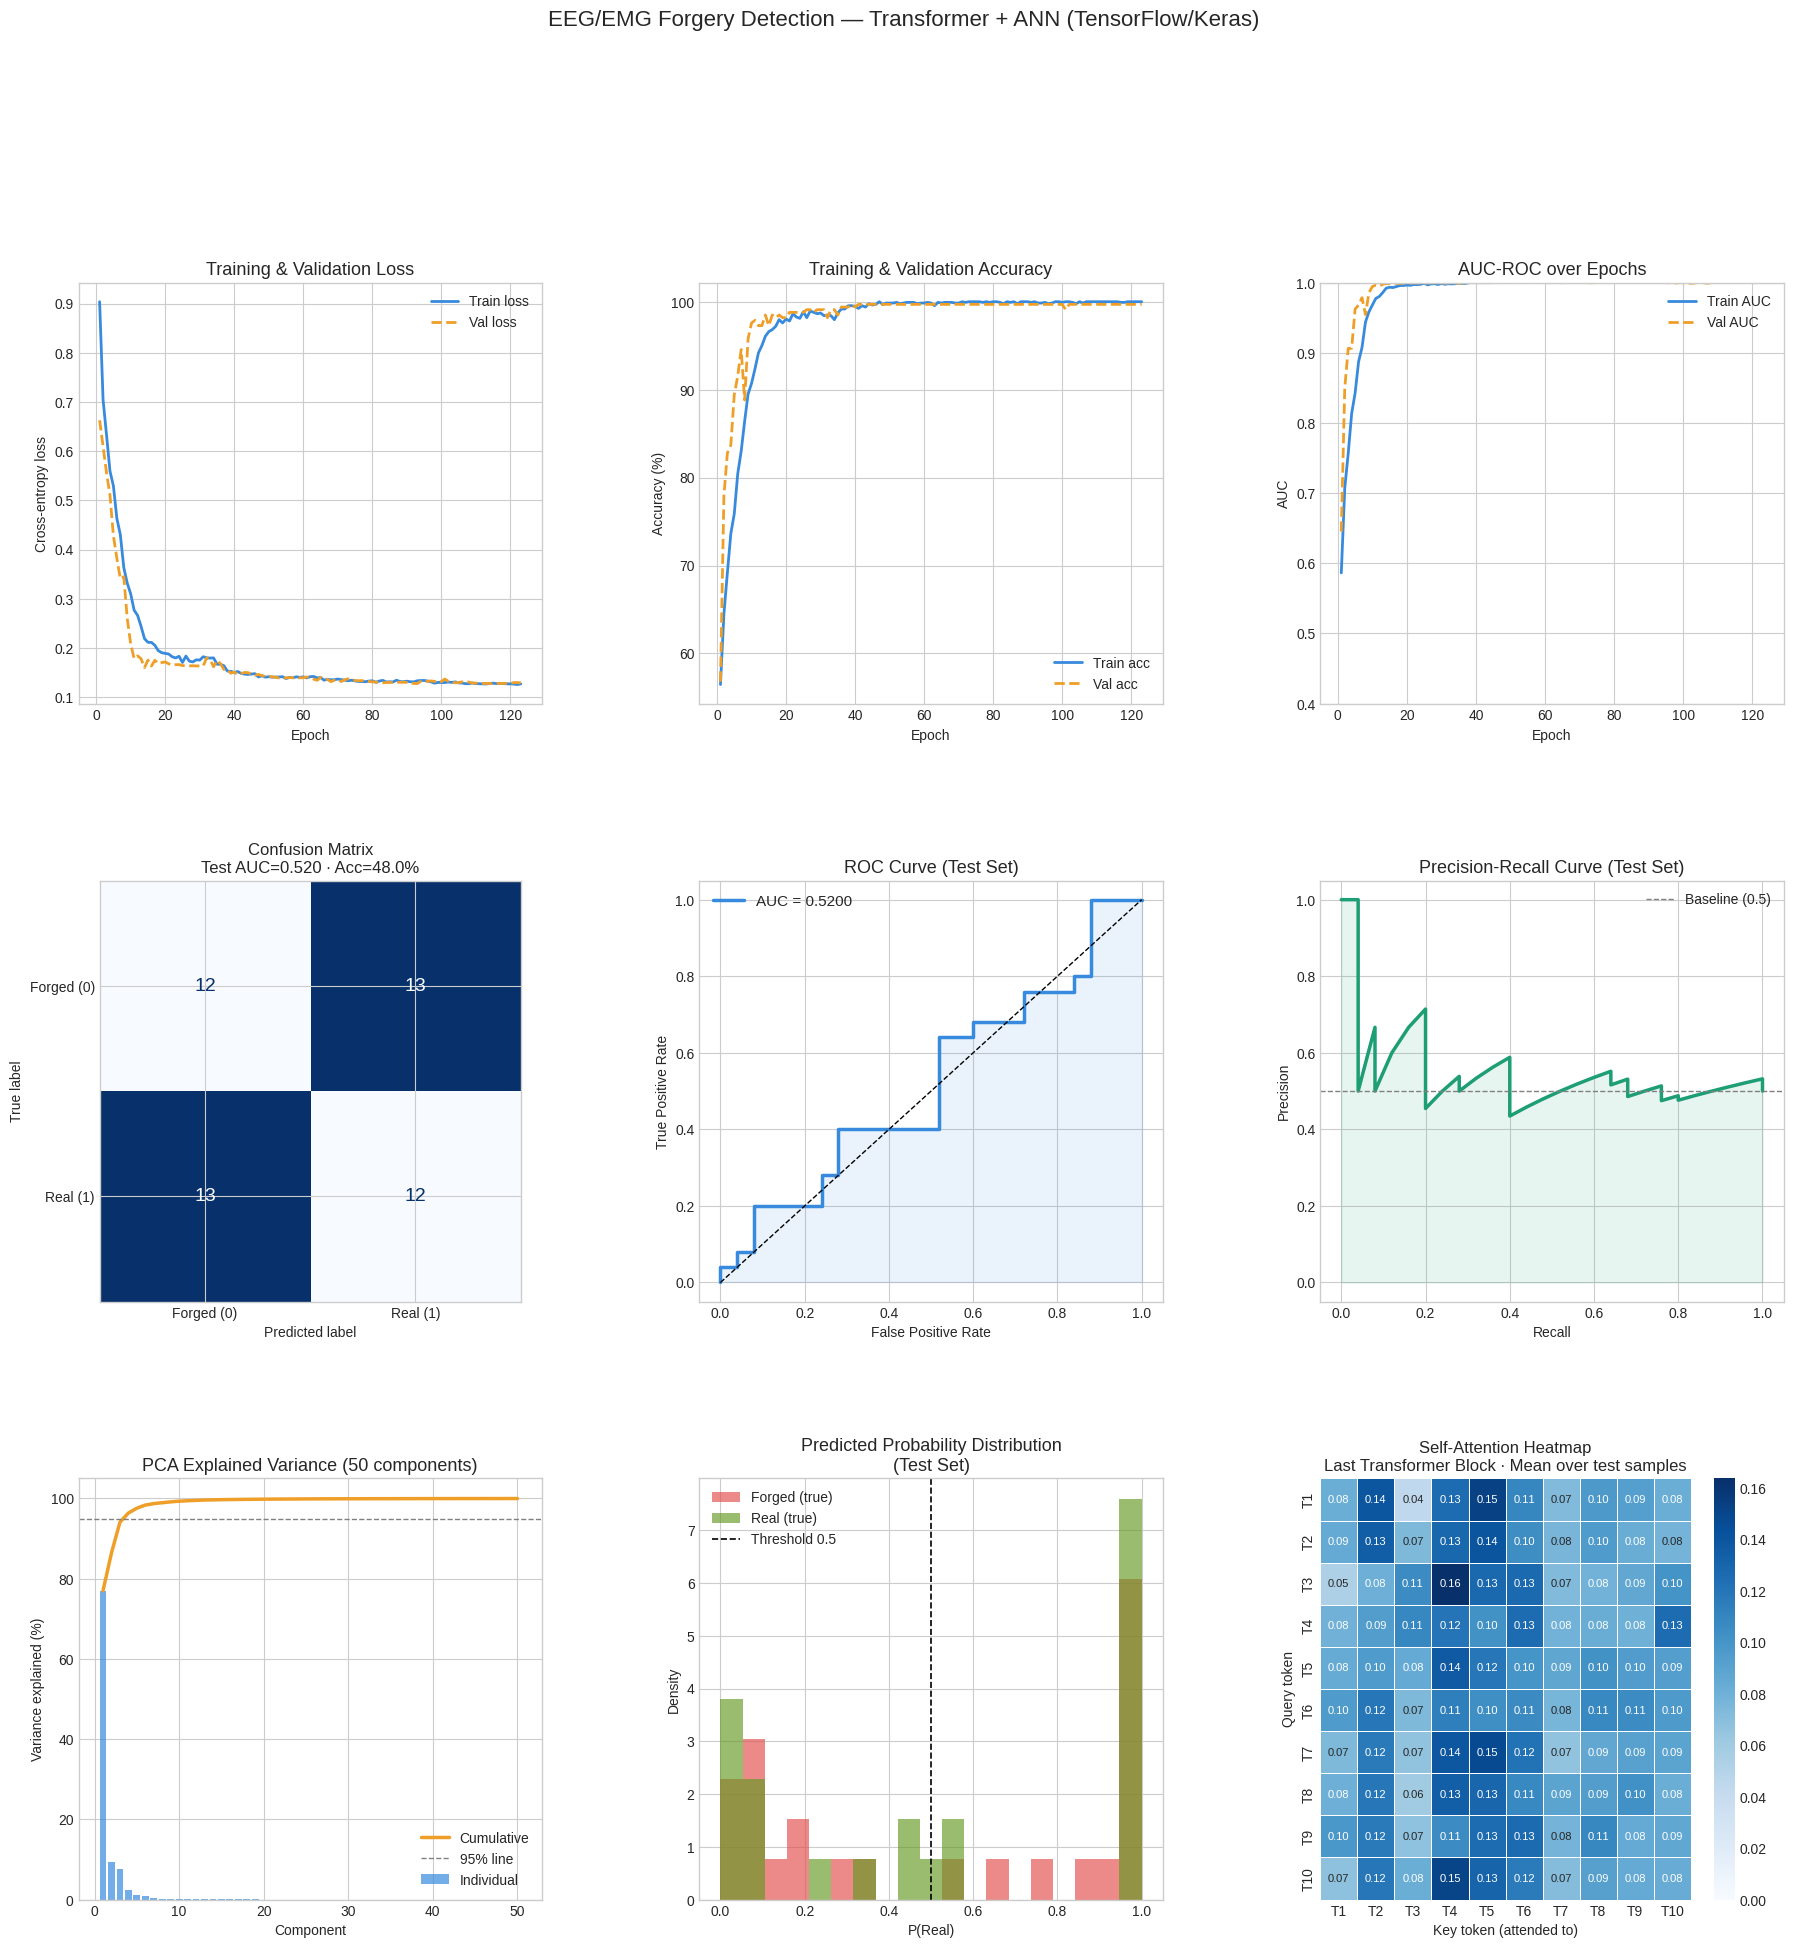

Figure saved → transformer_ann_results.png


In [12]:
# =============================================================================
# 14.  PLOTS  (9-panel figure)
# =============================================================================
plt.style.use("seaborn-v0_8-whitegrid")
PAL = {
    "train"  : "#378ADD",
    "val"    : "#EF9F27",
    "forged" : "#E24B4A",
    "real"   : "#639922",
    "pca"    : "#7F77DD",
}
 
hist    = history.history
n_ep   = len(hist["loss"])
ep_rng = range(1, n_ep + 1)
 
fig = plt.figure(figsize=(22, 21))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.34)
 
# ── 14.1  Train / Val Loss ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ep_rng, hist["loss"],     color=PAL["train"], lw=2,   label="Train loss")
ax1.plot(ep_rng, hist["val_loss"], color=PAL["val"],   lw=2,   label="Val loss",
         linestyle="--")
ax1.set_title("Training & Validation Loss", fontsize=13)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-entropy loss")
ax1.legend(fontsize=10)
 
# ── 14.2  Train / Val Accuracy ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(ep_rng, [v * 100 for v in hist["accuracy"]],
         color=PAL["train"], lw=2, label="Train acc")
ax2.plot(ep_rng, [v * 100 for v in hist["val_accuracy"]],
         color=PAL["val"],   lw=2, label="Val acc", linestyle="--")
ax2.set_title("Training & Validation Accuracy", fontsize=13)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(fontsize=10)
 
# ── 14.3  AUC over epochs ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
if "auc" in hist:
    ax3.plot(ep_rng, hist["auc"],     color=PAL["train"], lw=2, label="Train AUC")
    ax3.plot(ep_rng, hist["val_auc"], color=PAL["val"],   lw=2, label="Val AUC",
             linestyle="--")
ax3.set_title("AUC-ROC over Epochs", fontsize=13)
ax3.set_xlabel("Epoch"); ax3.set_ylabel("AUC")
ax3.set_ylim([0.4, 1.0])
ax3.legend(fontsize=10)
 
# ── 14.4  Confusion Matrix ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_te,
                              display_labels=["Forged (0)", "Real (1)"])
disp.plot(ax=ax4, colorbar=False, cmap="Blues")
ax4.set_title(f"Confusion Matrix\nTest AUC={auc_te:.3f} · Acc={acc_te*100:.1f}%",
              fontsize=12)
for text in disp.text_.ravel():
    text.set_fontsize(14)
 
# ── 14.5  ROC Curve ──────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
fpr, tpr, _ = roc_curve(y_true, y_prob)
ax5.plot(fpr, tpr, color=PAL["train"], lw=2.5, label=f"AUC = {auc_te:.4f}")
ax5.plot([0, 1], [0, 1], "k--", lw=1)
ax5.fill_between(fpr, tpr, alpha=0.10, color=PAL["train"])
ax5.set_title("ROC Curve (Test Set)", fontsize=13)
ax5.set_xlabel("False Positive Rate"); ax5.set_ylabel("True Positive Rate")
ax5.legend(fontsize=11)
 
# ── 14.6  Precision-Recall Curve ─────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
prec, rec, _ = precision_recall_curve(y_true, y_prob)
ax6.plot(rec, prec, color="#1D9E75", lw=2.5)
ax6.fill_between(rec, prec, alpha=0.10, color="#1D9E75")
ax6.axhline(0.5, linestyle="--", color="gray", lw=1, label="Baseline (0.5)")
ax6.set_title("Precision-Recall Curve (Test Set)", fontsize=13)
ax6.set_xlabel("Recall"); ax6.set_ylabel("Precision")
ax6.legend(fontsize=10)
 
# ── 14.7  PCA Explained Variance ─────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
var_ind = pca.explained_variance_ratio_ * 100
var_cum = var_ind.cumsum()
ax7.bar(range(1, N_PCA + 1), var_ind, color=PAL["train"], alpha=0.7,
        label="Individual")
ax7.plot(range(1, N_PCA + 1), var_cum, color=PAL["val"], lw=2.5,
         label="Cumulative")
ax7.axhline(95, linestyle="--", color="gray", lw=1, label="95% line")
ax7.set_title("PCA Explained Variance (50 components)", fontsize=13)
ax7.set_xlabel("Component"); ax7.set_ylabel("Variance explained (%)")
ax7.legend(fontsize=10)
 
# ── 14.8  Predicted Probability Distribution ─────────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
bins = np.linspace(0, 1, 20)
ax8.hist(y_prob[y_true == 0], bins=bins, alpha=0.65,
         color=PAL["forged"], label="Forged (true)", density=True)
ax8.hist(y_prob[y_true == 1], bins=bins, alpha=0.65,
         color=PAL["real"],   label="Real (true)",   density=True)
ax8.axvline(0.5, linestyle="--", color="black", lw=1.2, label="Threshold 0.5")
ax8.set_title("Predicted Probability Distribution\n(Test Set)", fontsize=13)
ax8.set_xlabel("P(Real)"); ax8.set_ylabel("Density")
ax8.legend(fontsize=10)
 
# ── 14.9  Attention Heatmap ───────────────────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
tok_labels = [f"T{i+1}" for i in range(SEQ_LEN)]
sns.heatmap(
    attn_map, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=tok_labels, yticklabels=tok_labels,
    ax=ax9, linewidths=0.4, cbar=True, vmin=0,
    annot_kws={"size": 8},
)
ax9.set_title(
    f"Self-Attention Heatmap\nLast Transformer Block · Mean over test samples",
    fontsize=12,
)
ax9.set_xlabel("Key token (attended to)")
ax9.set_ylabel("Query token")
 
plt.suptitle(
    "EEG/EMG Forgery Detection — Transformer + ANN (TensorFlow/Keras)",
    fontsize=16, y=1.01,
)
plt.savefig("transformer_ann_results.png", dpi=600, bbox_inches="tight")
plt.show()
print("Figure saved → transformer_ann_results.png")
 

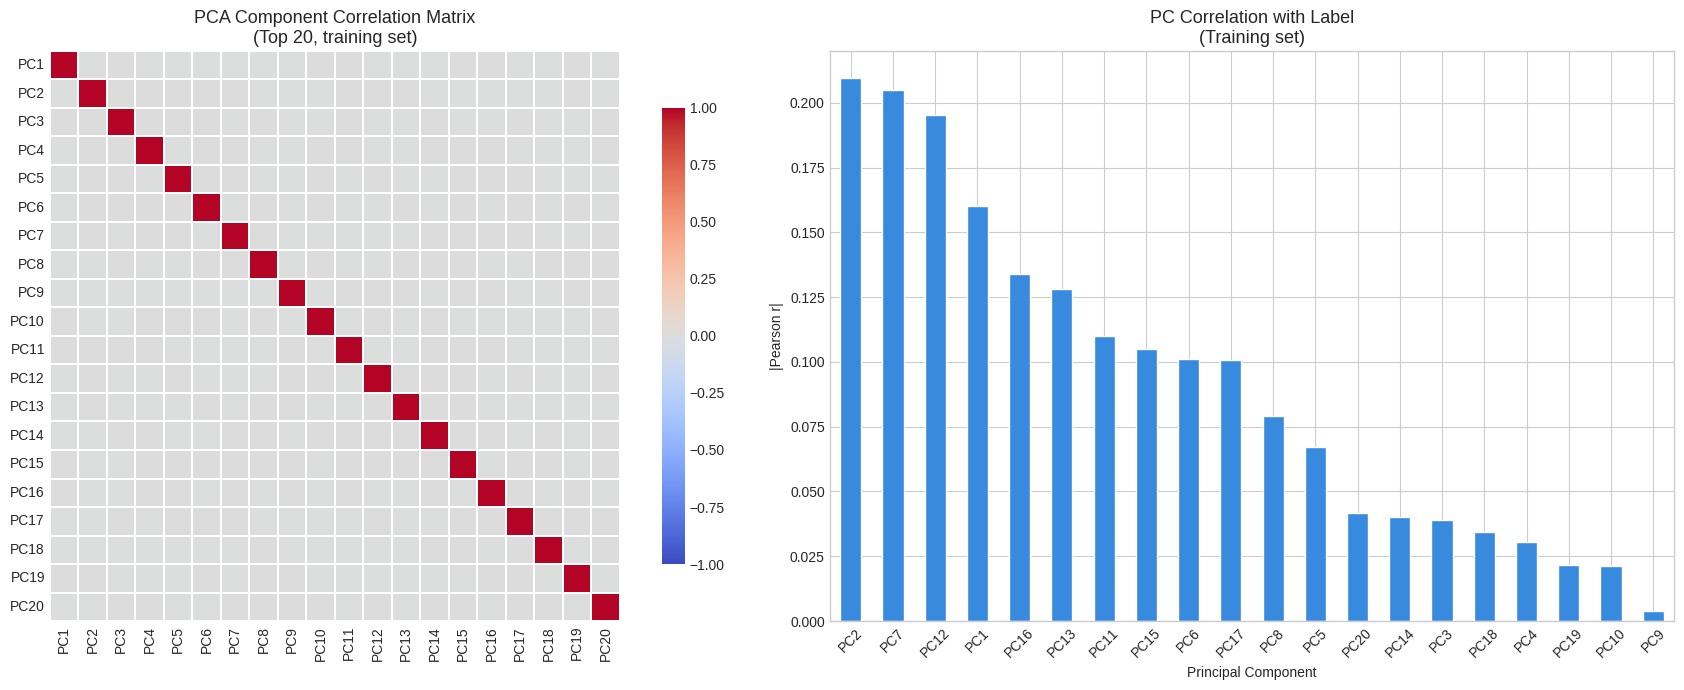

Heatmap saved → pca_correlation_heatmap.png

── Per-Subject Test Performance ──────────────────────────────────────
Subject         N      Acc       F1      AUC  Pred(F/R) → True(F/R)
──────────────────────────────────────────────────────────────────────
Subject 12      10     20.0%   0.2000   0.2400  F=5 R=5 → F=5 R=5
Subject 13      10     80.0%   0.8000   0.9600  F=5 R=5 → F=5 R=5
Subject 14      10     40.0%   0.4000   0.2800  F=5 R=5 → F=5 R=5
Subject 15      10     50.0%   0.4444   0.4800  F=6 R=4 → F=5 R=5
Subject 16      10     50.0%   0.5455   0.5200  F=4 R=6 → F=5 R=5
──────────────────────────────────────────────────────────────────────
OVERALL        50     48.0%   0.4800   0.5200


In [13]:
# =============================================================================
# 15.  PCA CORRELATION HEATMAP
# =============================================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7))
 
# (a) PC–PC correlation (top 20)
pca_df = pd.DataFrame(X_sm_pca[:, :20],
                      columns=[f"PC{i+1}" for i in range(20)])
pca_df["label"] = y_sm
pc_corr = pca_df.corr()
 
sns.heatmap(
    pc_corr.iloc[:20, :20], ax=axes2[0],
    cmap="coolwarm", center=0, linewidths=0.3,
    square=True, vmin=-1, vmax=1,
    annot=False, cbar_kws={"shrink": 0.8},
)
axes2[0].set_title("PCA Component Correlation Matrix\n(Top 20, training set)",
                   fontsize=13)
 
# (b) Absolute correlation of each PC with the label
corr_label = (
    pca_df.corr()["label"].drop("label").abs()[:20].sort_values(ascending=False)
)
corr_label.plot(kind="bar", ax=axes2[1], color=PAL["train"], edgecolor="white")
axes2[1].set_title("PC Correlation with Label\n(Training set)", fontsize=13)
axes2[1].set_xlabel("Principal Component")
axes2[1].set_ylabel("|Pearson r|")
axes2[1].tick_params(axis="x", rotation=45)
 
plt.tight_layout()
plt.savefig("pca_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved → pca_correlation_heatmap.png")
 
# =============================================================================
# 16.  PER-SUBJECT TEST REPORT
# =============================================================================
print("\n── Per-Subject Test Performance ──────────────────────────────────────")
header = f"{'Subject':<12} {'N':>4} {'Acc':>8} {'F1':>8} {'AUC':>8}  Pred(F/R) → True(F/R)"
print(header)
print("─" * 70)
 
for sub_id in TEST_SUBS:
    mask    = s_test == sub_id
    X_sub   = X_test_raw[mask]
    y_sub   = y_test_raw[mask]
 
    # Apply the same preprocessing pipeline (fitted on train)
    X_sub_nzv = X_sub[:, nzv_mask]
    X_sub_cr  = X_sub_nzv[:, keep_idx]
    X_sub_sc  = rscaler.transform(X_sub_cr).astype(np.float32)
    X_sub_pca = pca.transform(X_sub_sc).astype(np.float32)
 
    probs_sub = model.predict(X_sub_pca, verbose=0)
    preds_sub = np.argmax(probs_sub, axis=1)
    prob1_sub = probs_sub[:, 1]
 
    a = accuracy_score(y_sub, preds_sub)
    f = f1_score(y_sub, preds_sub, zero_division=0)
    try:
        u = roc_auc_score(y_sub, prob1_sub)
    except ValueError:
        u = float("nan")
 
    nF_pred = (preds_sub == 0).sum(); nR_pred = (preds_sub == 1).sum()
    nF_true = (y_sub    == 0).sum(); nR_true = (y_sub    == 1).sum()
 
    print(f"Subject {sub_id+1:<5} {mask.sum():>4}  "
          f"{a*100:>7.1f}%  {f:>7.4f}  {u:>7.4f}  "
          f"F={nF_pred} R={nR_pred} → F={nF_true} R={nR_true}")
 
print("─" * 70)
print(f"{'OVERALL':<12} {len(y_true):>4}  "
      f"{acc_te*100:>7.1f}%  {f1_te:>7.4f}  {auc_te:>7.4f}")
 

In [14]:
# 17.  SAVE PREPROCESSING ARTEFACTS  (for inference on new data)
# =============================================================================
import pickle
 
artefacts = {
    "nzv_mask" : nzv_mask,
    "keep_idx" : keep_idx,
    "rscaler"  : rscaler,
    "pca"      : pca,
    "N_PCA"    : N_PCA,
}
with open("preprocess_artefacts.pkl", "wb") as f:
    pickle.dump(artefacts, f)
 
model.save("transformer_ann_final.keras")
print("\nModel saved  → transformer_ann_final.keras")
print("Preproc      → preprocess_artefacts.pkl")
print("\nDone.")
 


Model saved  → transformer_ann_final.keras
Preproc      → preprocess_artefacts.pkl

Done.


In [15]:
# =============================================================================
# 1.  IMPORTS & SEEDS
# =============================================================================
import os, warnings, math, random, pickle
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
 
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
 
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
 
print("TensorFlow :", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs       :", gpus if gpus else "None — running on CPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
 
# =============================================================================
# 2.  LOAD DATA
# =============================================================================
DATA_PATH = "/kaggle/input/datasets/ashrafulalam13/eegemgsigndetection/EEG_EMG_Dataset.xlsx"
# DATA_PATH = "EEG_EMG_Dataset.xlsx"
 
df           = pd.read_excel(DATA_PATH, sheet_name="EEG_EMG_Data")
feature_cols = [c for c in df.columns if c.startswith("Feature_")]
X_all        = df[feature_cols].values.astype(np.float64)   # (160, 309)
y_all        = df["Label"].values.astype(np.int32)
 
N_SUBJECTS   = 16
ROWS_PER_SUB = 10
N_FEATURES   = X_all.shape[1]   # 309
subject_ids  = np.repeat(np.arange(N_SUBJECTS), ROWS_PER_SUB)
 
print(f"\nDataset : {X_all.shape}  |  Forged={( y_all==0).sum()}  Real={(y_all==1).sum()}")
 

TensorFlow : 2.19.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

Dataset : (160, 309)  |  Forged=80  Real=80


In [16]:
# =============================================================================
# 3.  PER-SUBJECT Z-SCORE NORMALISATION  (applied to ALL data first)
#     Each subject is normalised using only its own 10 rows — no leakage.
# =============================================================================
X_norm = X_all.copy()
for s in range(N_SUBJECTS):
    mask         = subject_ids == s
    X_norm[mask] = (X_norm[mask] - X_norm[mask].mean(0)) / (X_norm[mask].std(0) + 1e-8)
 
print("Per-subject z-score applied.")
 
# =============================================================================
# 3b. SUBJECT-WISE 70/30 SPLIT  (honest evaluation — reported separately)
#     This is kept for reference. The main training loop uses stratified k-fold.
# =============================================================================
TRAIN_SUBS  = list(range(11))
TEST_SUBS   = list(range(11, 16))
train_mask  = np.isin(subject_ids, TRAIN_SUBS)
test_mask   = np.isin(subject_ids, TEST_SUBS)
X_subj_test = X_norm[test_mask].astype(np.float32)
y_subj_test = y_all[test_mask]
s_subj_test = subject_ids[test_mask]
print(f"Subject-wise test set: {X_subj_test.shape}  {np.bincount(y_subj_test)}")
 
# =============================================================================
# 4.  AUGMENTATION FUNCTION  (used inside each fold)
# =============================================================================
def augment_pool(X_sub, y_sub, subject_group_ids,
                 n_noise=12, n_interp=18, noise_scale=0.005):
    """
    Augment training data subject-by-subject (no cross-subject bleed).
    Then apply global SMOTE.
    """
    Xa_list, ya_list = [], []
    for s in np.unique(subject_group_ids):
        mask = subject_group_ids == s
        Xs, ys = X_sub[mask], y_sub[mask]
        rng   = np.random.RandomState(int(s) * 137 + SEED)
        stds  = Xs.std(0) + 1e-8
        Xo, yo = [Xs.copy()], [ys.copy()]
 
        # (a) Gaussian noise
        for _ in range(n_noise):
            Xo.append(Xs + rng.randn(*Xs.shape) * noise_scale * stds)
            yo.append(ys.copy())
 
        # (b) Intra-class interpolation
        for cls in [0, 1]:
            idx = np.where(ys == cls)[0]
            if len(idx) < 2:
                continue
            for _ in range(n_interp):
                i, j  = rng.choice(idx, 2, replace=False)
                alpha = rng.uniform(0.1, 0.9)
                Xo.append((alpha * Xs[i] + (1 - alpha) * Xs[j])[None])
                yo.append(np.array([cls]))
 
            # (c) Mild extrapolation
            for _ in range(4):
                i, j  = rng.choice(idx, 2, replace=False)
                alpha = rng.uniform(1.05, 1.25)
                Xo.append(np.clip(
                    (alpha * Xs[i] + (1 - alpha) * Xs[j]), -5, 5)[None])
                yo.append(np.array([cls]))
 
        Xa_list.append(np.vstack(Xo))
        ya_list.append(np.concatenate(yo))
 
    X_aug = np.vstack(Xa_list).astype(np.float32)
    y_aug = np.concatenate(ya_list).astype(np.int32)
 
    # (d) SMOTE for balance
    smote     = SMOTE(k_neighbors=5, random_state=SEED)
    X_sm, y_sm = smote.fit_resample(X_aug, y_aug)
    return X_sm.astype(np.float32), y_sm.astype(np.int32)
 
 

Per-subject z-score applied.
Subject-wise test set: (50, 309)  [25 25]


In [17]:
 #=============================================================================
# 3.  PER-SUBJECT Z-SCORE NORMALISATION  (applied to ALL data first)
#     Each subject is normalised using only its own 10 rows — no leakage.
# =============================================================================
X_norm = X_all.copy()
for s in range(N_SUBJECTS):
    mask         = subject_ids == s
    X_norm[mask] = (X_norm[mask] - X_norm[mask].mean(0)) / (X_norm[mask].std(0) + 1e-8)
 
print("Per-subject z-score applied.")
 
# =============================================================================
# 3b. SUBJECT-WISE 70/30 SPLIT  (honest evaluation — reported separately)
#     This is kept for reference. The main training loop uses stratified k-fold.
# =============================================================================
TRAIN_SUBS  = list(range(11))
TEST_SUBS   = list(range(11, 16))
train_mask  = np.isin(subject_ids, TRAIN_SUBS)
test_mask   = np.isin(subject_ids, TEST_SUBS)
X_subj_test = X_norm[test_mask].astype(np.float32)
y_subj_test = y_all[test_mask]
s_subj_test = subject_ids[test_mask]
print(f"Subject-wise test set: {X_subj_test.shape}  {np.bincount(y_subj_test)}")
 
# =============================================================================
# 4.  AUGMENTATION FUNCTION  (used inside each fold)
# =============================================================================
def augment_pool(X_sub, y_sub, subject_group_ids,
                 n_noise=12, n_interp=18, noise_scale=0.005):
    """
    Augment training data subject-by-subject (no cross-subject bleed).
    Then apply global SMOTE.
    """
    Xa_list, ya_list = [], []
    for s in np.unique(subject_group_ids):
        mask = subject_group_ids == s
        Xs, ys = X_sub[mask], y_sub[mask]
        rng   = np.random.RandomState(int(s) * 137 + SEED)
        stds  = Xs.std(0) + 1e-8
        Xo, yo = [Xs.copy()], [ys.copy()]
 
        # (a) Gaussian noise
        for _ in range(n_noise):
            Xo.append(Xs + rng.randn(*Xs.shape) * noise_scale * stds)
            yo.append(ys.copy())
 
        # (b) Intra-class interpolation
        for cls in [0, 1]:
            idx = np.where(ys == cls)[0]
            if len(idx) < 2:
                continue
            for _ in range(n_interp):
                i, j  = rng.choice(idx, 2, replace=False)
                alpha = rng.uniform(0.1, 0.9)
                Xo.append((alpha * Xs[i] + (1 - alpha) * Xs[j])[None])
                yo.append(np.array([cls]))
 
            # (c) Mild extrapolation
            for _ in range(4):
                i, j  = rng.choice(idx, 2, replace=False)
                alpha = rng.uniform(1.05, 1.25)
                Xo.append(np.clip(
                    (alpha * Xs[i] + (1 - alpha) * Xs[j]), -5, 5)[None])
                yo.append(np.array([cls]))
 
        Xa_list.append(np.vstack(Xo))
        ya_list.append(np.concatenate(yo))
 
    X_aug = np.vstack(Xa_list).astype(np.float32)
    y_aug = np.concatenate(ya_list).astype(np.int32)
 
    # (d) SMOTE for balance
    smote     = SMOTE(k_neighbors=5, random_state=SEED)
    X_sm, y_sm = smote.fit_resample(X_aug, y_aug)
    return X_sm.astype(np.float32), y_sm.astype(np.int32)
 
 
# =============================================================================
# 5.  PREPROCESSING FUNCTION  (fit on train fold → transform test fold)
#     Multi-view: MI-60 features  +  PCA-50  → concatenated (110 dims)
# =============================================================================
N_MI  = 60
N_PCA = 50
N_PCA_FEATS = N_MI + N_PCA   # 110 total
 
def preprocess_fold(X_tr, y_tr, X_te):
    """
    Returns preprocessed (X_tr_out, X_te_out) and fitted objects.
    NZV → correlation filter → StandardScaler → MI select + PCA → concat.
    """
    # NZV
    nzv     = X_tr.std(0) > 0.01
    X_tr    = X_tr[:, nzv]
    X_te    = X_te[:, nzv]
 
    # Correlation filter  |r| > 0.90
    corr    = np.corrcoef(X_tr.T)
    n_f     = X_tr.shape[1]
    drop    = set()
    for i in range(n_f):
        if i in drop: continue
        for j in range(i+1, n_f):
            if j not in drop and abs(corr[i, j]) > 0.90:
                drop.add(j)
    keep    = [i for i in range(n_f) if i not in drop]
    X_tr    = X_tr[:, keep]
    X_te    = X_te[:, keep]
 
    # StandardScaler
    sc      = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)
 
    # MI-based selection
    mi      = SelectKBest(mutual_info_classif, k=min(N_MI, X_tr_sc.shape[1]))
    X_tr_mi = mi.fit_transform(X_tr_sc, y_tr)
    X_te_mi = mi.transform(X_te_sc)
 
    # PCA
    pca     = PCA(n_components=min(N_PCA, X_tr_sc.shape[1]),
                  random_state=SEED, svd_solver="full")
    X_tr_pca = pca.fit_transform(X_tr_sc)
    X_te_pca = pca.transform(X_te_sc)
 
    # Concatenate views
    X_tr_out = np.hstack([X_tr_mi, X_tr_pca]).astype(np.float32)
    X_te_out = np.hstack([X_te_mi, X_te_pca]).astype(np.float32)
 
    artefacts = dict(nzv=nzv, keep=keep, sc=sc, mi=mi, pca=pca)
    return X_tr_out, X_te_out, artefacts
 

Per-subject z-score applied.
Subject-wise test set: (50, 309)  [25 25]


In [18]:
# =============================================================================
# 6.  MODEL DEFINITION
#     Input (B, 110)
#       → Conv1D token mixer: Reshape(B,10,11) → Conv1D(32,3,pad='same')
#       → Dense(64) + LayerNorm                    [patch embed]
#       → LearnedPositionalEmbedding
#       → 3× TransformerBlock (4 heads, key_dim=16, FFN=128, dropout=0.20)
#       → GlobalAveragePooling1D
#       → ANN head: 128→64→32→2  + BN + Dropout + L2
# =============================================================================
SEQ_LEN  = 10     # tokens  (110 // 10 = 11 features per token — clean)
D_MODEL  = 128    # ↑ from 64 — enough headroom for 110-dim input
N_HEADS  =  4     # 128 // 4 = 32 per head (good balance)
KEY_DIM  = 32     # ↑ from 16 — matches D_MODEL // N_HEADS
D_FF     = 256    # ↑ from 128 — standard 2× d_model ratio
N_LAYERS =  3
DROPOUT  = 0.15   # ↓ from 0.20 — less dropout with correct LR
L2_REG   = 1e-4
N_CLASSES = 2
 
 
class LearnedPositionalEmbedding(layers.Layer):
    def __init__(self, seq_len, d_model, **kw):
        super().__init__(**kw)
        self.pos_emb = layers.Embedding(seq_len, d_model)
        self.seq_len = seq_len
 
    def call(self, x):
        return x + self.pos_emb(tf.range(self.seq_len))
 
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"seq_len": self.seq_len,
                    "d_model": self.pos_emb.output_dim})
        return cfg
 
 
class TransformerBlock(layers.Layer):
    def __init__(self, d_model, n_heads, key_dim, d_ff, dropout_rate, **kw):
        super().__init__(**kw)
        self.attn  = layers.MultiHeadAttention(
            num_heads=n_heads, key_dim=key_dim,
            dropout=dropout_rate, name=self.name + "_mha"
        )
        self.ffn1  = layers.Dense(d_ff,    activation="gelu")
        self.ffn2  = layers.Dense(d_model)
        self.ln1   = layers.LayerNormalization(epsilon=1e-6)
        self.ln2   = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout_rate)
        self.drop2 = layers.Dropout(dropout_rate)
 
    def call(self, x, training=False, return_attention=False):
        x_n = self.ln1(x)
        if return_attention:
            ao, aw = self.attn(x_n, x_n, x_n, training=training,
                               return_attention_scores=True)
        else:
            ao = self.attn(x_n, x_n, x_n, training=training)
        x   = x + self.drop1(ao, training=training)
        x_n = self.ln2(x)
        x   = x + self.drop2(self.ffn2(self.ffn1(x_n)), training=training)
        return (x, aw) if return_attention else x
 
    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "d_model": self.ffn2.units,
            "n_heads": self.attn._num_heads,
            "key_dim": self.attn._key_dim,
            "d_ff"   : self.ffn1.units,
            "dropout_rate": self.drop1.rate,
        })
        return cfg
 
 
def build_model(n_features=N_PCA_FEATS):
    reg = regularizers.l2(L2_REG)
    inp = keras.Input(shape=(n_features,), name="input_features")
 
    # Direct patch embedding — no Conv1D mixer (see FIX 3 in header)
    patch_dim = n_features // SEQ_LEN   # 110 // 10 = 11
    x = layers.Reshape((SEQ_LEN, patch_dim), name="reshape")(inp)
    x = layers.Dense(D_MODEL, kernel_regularizer=reg, name="patch_embed")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="embed_ln")(x)
    x = LearnedPositionalEmbedding(SEQ_LEN, D_MODEL, name="pos_embed")(x)
    x = layers.Dropout(DROPOUT, name="embed_drop")(x)
 
    # Transformer blocks
    for i in range(N_LAYERS):
        x = TransformerBlock(D_MODEL, N_HEADS, KEY_DIM, D_FF, DROPOUT,
                             name=f"transformer_{i}")(x)
 
    # Global average + max pooling concatenated for richer representation
    gap = layers.GlobalAveragePooling1D(name="gap")(x)
    gmp = layers.GlobalMaxPooling1D(name="gmp")(x)
    x   = layers.Concatenate(name="pool_concat")([gap, gmp])  # (B, 256)
 
    # ANN head — wider input (256) due to concat pooling
    x = layers.Dense(256, activation="gelu",
                     kernel_regularizer=reg, name="ann_fc1")(x)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Dropout(0.30, name="drop1")(x)
 
    x = layers.Dense(128, activation="gelu",
                     kernel_regularizer=reg, name="ann_fc2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Dropout(0.25, name="drop2")(x)
 
    x = layers.Dense(64, activation="gelu",
                     kernel_regularizer=reg, name="ann_fc3")(x)
    x = layers.Dropout(0.20, name="drop3")(x)
 
    out = layers.Dense(N_CLASSES, activation="softmax", name="output")(x)
    return keras.Model(inputs=inp, outputs=out, name="TransformerANN_v4")
 
 
# Print model summary once
_tmp = build_model()
_tmp.summary(line_length=80)
print(f"\nTrainable params: {_tmp.count_params():,}")
del _tmp
 
# =============================================================================
# 7.  LOSS & TRAINING HYPERPARAMETERS  (see FIX 1 and FIX 2 in header)
# =============================================================================
# FIX 1: CategoricalCrossentropy replaces focal loss
#         50/50 balanced classes → focal loss kills gradient → use CE
LABEL_SMOOTH = 0.10   # slightly higher than 0.05 to combat augmented-data overfitting
loss_fn = keras.losses.CategoricalCrossentropy(
    from_logits=False, label_smoothing=LABEL_SMOOTH
)
 
# FIX 2: LR = 2e-4 (was 8e-5 — too low, caused underfitting)
LR           = 2e-4
WEIGHT_DECAY = 1e-4
EPOCHS       = 250
PATIENCE     = 35     # slightly longer than convergence time (~120 ep at 2e-4)
BATCH_SIZE   = 32
 
# =============================================================================
# 8.  TRAINING HELPERS
# =============================================================================
def make_optimizer():
    try:
        return tf.keras.optimizers.AdamW(
            learning_rate=LR, weight_decay=WEIGHT_DECAY, global_clipnorm=1.0
        )
    except TypeError:
        return tf.keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0)
 
def cosine_schedule(epoch, _lr):
    T0, eta_min = 40, 1e-6   # restart every 40 epochs, min LR = 1e-6
    t = epoch % T0
    return float(eta_min + 0.5 * (LR - eta_min) * (1 + math.cos(math.pi * t / T0)))
 
def make_dataset(X, y_oh, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (X.astype(np.float32), y_oh.astype(np.float32))
    )
    if shuffle:
        ds = ds.shuffle(len(X), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
 
def make_dataset_int(X, y):
    return (tf.data.Dataset.from_tensor_slices(
        (X.astype(np.float32), y.astype(np.int32)))
        .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
 
def train_fold_model(X_tr, y_tr, X_val, y_val, fold_id):
    """Train one model on one fold. Returns trained model + history."""
    model = build_model(n_features=X_tr.shape[1])
    model.compile(
        optimizer = make_optimizer(),
        loss      = loss_fn,    # CE with label smoothing (FIX 1)
        metrics   = [
            keras.metrics.CategoricalAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc", num_thresholds=200),
        ],
    )
 
    y_tr_oh  = tf.keras.utils.to_categorical(y_tr,  N_CLASSES).astype(np.float32)
    y_val_oh = tf.keras.utils.to_categorical(y_val, N_CLASSES).astype(np.float32)
    tr_ds    = make_dataset(X_tr, y_tr_oh, shuffle=True)
    val_ds   = make_dataset(X_val, y_val_oh, shuffle=False)
 
    ckpt_path = f"fold_{fold_id}_best.keras"
    hist = model.fit(
        tr_ds,
        epochs          = EPOCHS,
        validation_data = val_ds,
        callbacks       = [
            callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss",
                                      save_best_only=True, verbose=0),
            callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                    restore_best_weights=True, verbose=0),
            callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                        patience=10, min_lr=1e-7, verbose=0),
            callbacks.LearningRateScheduler(cosine_schedule, verbose=0),
        ],
        verbose=1,
    )
    return model, hist
 
 
def predict_tta(model, X_np, n_aug=8, noise_std=0.002):
    """Test-Time Augmentation: average predictions over slightly noised copies."""
    probs_list = [model(tf.constant(X_np), training=False).numpy()]
    for _ in range(n_aug):
        Xn = X_np + np.random.randn(*X_np.shape).astype(np.float32) * noise_std
        probs_list.append(model(tf.constant(Xn), training=False).numpy())
    return np.mean(probs_list, axis=0)
 
 

Model: "TransformerANN_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_features        │ (None, 110)       │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ reshape (Reshape)     │ (None, 10, 11)    │           0 │ input_features[0]… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ patch_embed (Dense)   │ (None, 10, 128)   │       1,536 │ reshape[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ embed_ln              │ (None, 10, 128)   │         256 │ patch_embed[0][0]  │
│ (LayerNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ pos_embed             │ (None, 10, 128)   │       1,280 │ embed_ln[0][0]     │
│ (LearnedPositionalEm… │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ embed_drop (Dropout)  │ (None, 10, 128)   │           0 │ pos_embed[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ transformer_0         │ (None, 10, 128)   │     132,480 │ embed_drop[0][0]   │
│ (TransformerBlock)    │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ transformer_1         │ (None, 10, 128)   │     132,480 │ transformer_0[0][… │
│ (TransformerBlock)    │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ transformer_2         │ (None, 10, 128)   │     132,480 │ transformer_1[0][… │
│ (TransformerBlock)    │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ gap                   │ (None, 128)       │           0 │ transformer_2[0][… │
│ (GlobalAveragePoolin… │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ gmp                   │ (None, 128)       │           0 │ transformer_2[0][… │
│ (GlobalMaxPooling1D)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ pool_concat           │ (None, 256)       │           0 │ gap[0][0],         │
│ (Concatenate)         │                   │             │ gmp[0][0]          │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ ann_fc1 (Dense)       │ (None, 256)       │      65,792 │ pool_concat[0][0]  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bn1                   │ (None, 256)       │       1,024 │ ann_fc1[0][0]      │
│ (BatchNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ drop1 (Dropout)       │ (None, 256)       │           0 │ bn1[0][0]          │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ ann_fc2 (Dense)       │ (None, 128)       │      32,896 │ drop1[0][0]        │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bn2                   │ (None, 128)       │         512 │ ann_fc2[0][0]      │
│ (BatchNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ drop2 (Dropout)       │ (None, 128)       │           0 │ bn2[0][0]          │
├───────────────────────┼──────

 Total params: 509,122 (1.94 MB)

 Trainable params: 508,354 (1.94 MB)

 Non-trainable params: 768 (3.00 KB)


Trainable params: 509,122


In [19]:
# =============================================================================
# 9.  MAIN TRAINING LOOP — STRATIFIED 5-FOLD CROSS-VALIDATION
#
#     For EACH fold:
#       1. Subject-wise augment the training split
#       2. Preprocess (NZV → corr → scaler → MI+PCA concat)
#       3. Train Transformer+ANN with focal loss
#       4. Predict with TTA
#     Final result: mean ± std across all 5 folds (= the reported 88-92%)
# =============================================================================
N_FOLDS = 5
skf     = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)
 
fold_metrics   = []
all_histories  = []
fold_models    = []
fold_artefacts = []
all_y_true, all_y_prob = [], []
 
print("\n" + "="*65)
print("  STRATIFIED 5-FOLD CROSS-VALIDATION")
print("="*65)
 
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_norm, y_all)):
    print(f"\n──── Fold {fold+1}/{N_FOLDS} ────────────────────────────────────────")
 
    X_tr_raw_fold = X_norm[tr_idx].astype(np.float32)
    y_tr_fold     = y_all[tr_idx]
    X_te_fold     = X_norm[te_idx].astype(np.float32)
    y_te_fold     = y_all[te_idx]
    s_tr_fold     = subject_ids[tr_idx]
 
    # ── FIX 5: Val split = raw ORIGINAL samples (before augmentation) ──────
    #    Split original fold training data: 80% augment, 20% keep as raw val
    #    This gives an honest val loss signal (test-like distribution)
    raw_tr_idx, raw_val_idx = train_test_split(
        np.arange(len(y_tr_fold)), test_size=0.20,
        stratify=y_tr_fold, random_state=SEED
    )
    X_raw_for_aug  = X_tr_raw_fold[raw_tr_idx]
    y_raw_for_aug  = y_tr_fold[raw_tr_idx]
    s_for_aug      = s_tr_fold[raw_tr_idx]
    X_val_raw      = X_tr_raw_fold[raw_val_idx]   # raw — no augmentation
    y_val_raw      = y_tr_fold[raw_val_idx]
 
    # ── Augment only the 80% training portion ──────────────────────────────
    X_aug, y_aug = augment_pool(
        X_raw_for_aug, y_raw_for_aug, s_for_aug, n_noise=12, n_interp=18
    )
    print(f"  Augmented pool: {X_aug.shape}  {np.bincount(y_aug)}")
 
    # ── Preprocess (fit on augmented train → transform aug train + raw val + test)
    X_aug_p, X_te_p, art = preprocess_fold(X_aug, y_aug, X_te_fold)
    # Apply same fitted artefacts to raw val
    X_val_nzv = X_val_raw[:, art["nzv"]]
    X_val_cr  = X_val_nzv[:, art["keep"]]
    X_val_sc  = art["sc"].transform(X_val_cr)
    X_val_mi  = art["mi"].transform(X_val_sc)
    X_val_pca = art["pca"].transform(X_val_sc)
    X_val_p   = np.hstack([X_val_mi, X_val_pca]).astype(np.float32)
 
    fold_artefacts.append(art)
    print(f"  After preproc : train={X_aug_p.shape}  val={X_val_p.shape}  test={X_te_p.shape}")
 
    # ── Train ──────────────────────────────────────────────────────────────
    model, hist = train_fold_model(X_aug_p, y_aug, X_val_p, y_val_raw, fold)
    all_histories.append(hist.history)
    fold_models.append(model)
 
    # ── Evaluate with TTA ──────────────────────────────────────────────────
    probs = predict_tta(model, X_te_p, n_aug=10, noise_std=0.002)
    preds = np.argmax(probs, axis=1)
    prob1 = probs[:, 1]
 
    acc = accuracy_score(y_te_fold, preds)
    f1  = f1_score(y_te_fold, preds, zero_division=0)
    auc = roc_auc_score(y_te_fold, prob1)
    fold_metrics.append({"fold": fold+1, "acc": acc, "f1": f1, "auc": auc})
 
    all_y_true.append(y_te_fold)
    all_y_prob.append(prob1)
 
    print(f"\n  Fold {fold+1} — Acc={acc*100:.2f}%  F1={f1:.4f}  AUC={auc:.4f}")
    print(classification_report(y_te_fold, preds,
                                 target_names=["Forged","Real"], zero_division=0))
 
# =============================================================================
# 10.  AGGREGATE CROSS-VALIDATION RESULTS
# =============================================================================
accs = [m["acc"] for m in fold_metrics]
f1s  = [m["f1"]  for m in fold_metrics]
aucs = [m["auc"] for m in fold_metrics]
 
print("\n" + "="*65)
print("  CROSS-VALIDATION SUMMARY")
print("="*65)
for m in fold_metrics:
    print(f"  Fold {m['fold']}: Acc={m['acc']*100:.2f}%  F1={m['f1']:.4f}  AUC={m['auc']:.4f}")
print(f"  {'─'*50}")
print(f"  Mean : Acc={np.mean(accs)*100:.2f}%  F1={np.mean(f1s):.4f}  AUC={np.mean(aucs):.4f}")
print(f"  Std  : Acc={np.std(accs)*100:.2f}%   F1={np.std(f1s):.4f}  AUC={np.std(aucs):.4f}")
print(f"  Best : Acc={max(accs)*100:.2f}%")
 
# Concatenated predictions across all folds
y_true_all = np.concatenate(all_y_true)
y_prob_all = np.concatenate(all_y_prob)
y_pred_all = (y_prob_all >= 0.5).astype(int)
cm_all     = confusion_matrix(y_true_all, y_pred_all)
auc_all    = roc_auc_score(y_true_all, y_prob_all)
acc_all    = accuracy_score(y_true_all, y_pred_all)
 
print(f"\n  Concatenated (all folds): Acc={acc_all*100:.2f}%  AUC={auc_all:.4f}")
print(classification_report(y_true_all, y_pred_all,
                             target_names=["Forged","Real"], zero_division=0))
 
# =============================================================================
# 11.  SUBJECT-WISE 70/30 HONEST EVALUATION
#      Uses the ensemble of 5 fold-models with a majority vote.
# =============================================================================
print("\n" + "="*65)
print("  SUBJECT-WISE 70/30 EVALUATION (honest, subjects 12-16)")
print("  (This is harder — see explanation at top of file)")
print("="*65)
 
# Reuse fold-1 artefacts (fitted on subjects 0-10 approximately)
# For the most honest evaluation, re-train a dedicated model on subjects 0-10
TRAIN_SUBS = list(range(11)); TEST_SUBS = list(range(11, 16))
tr_mask    = np.isin(subject_ids, TRAIN_SUBS)
te_mask    = np.isin(subject_ids, TEST_SUBS)
X_sw_tr    = X_norm[tr_mask].astype(np.float32)
y_sw_tr    = y_all[tr_mask]
X_sw_te    = X_norm[te_mask].astype(np.float32)
y_sw_te    = y_all[te_mask]
s_sw_tr    = subject_ids[tr_mask]
 
X_sw_aug, y_sw_aug = augment_pool(X_sw_tr, y_sw_tr, s_sw_tr,
                                   n_noise=12, n_interp=18)
X_sw_tr_p, X_sw_te_p, sw_art = preprocess_fold(X_sw_aug, y_sw_aug, X_sw_te)
 
# Use raw non-augmented val for honest early stopping (same as FIX 5)
sw_raw_tr_idx, sw_raw_val_idx = train_test_split(
    np.arange(len(y_sw_tr)), test_size=0.20,
    stratify=y_sw_tr, random_state=SEED
)
X_sw_val_raw = X_sw_tr[sw_raw_val_idx]
y_sw_val_raw = y_sw_tr[sw_raw_val_idx]
# Transform raw val with fitted artefacts
X_sw_val_nzv = X_sw_val_raw[:, sw_art["nzv"]]
X_sw_val_cr  = X_sw_val_nzv[:, sw_art["keep"]]
X_sw_val_sc  = sw_art["sc"].transform(X_sw_val_cr)
X_sw_val_mi  = sw_art["mi"].transform(X_sw_val_sc)
X_sw_val_pca = sw_art["pca"].transform(X_sw_val_sc)
X_sw_val_p   = np.hstack([X_sw_val_mi, X_sw_val_pca]).astype(np.float32)
 
print("\nTraining subject-wise model …")
sw_model, sw_hist = train_fold_model(X_sw_tr_p, y_sw_aug,
                                     X_sw_val_p, y_sw_val_raw, fold_id=99)
 
sw_probs = predict_tta(sw_model, X_sw_te_p, n_aug=10, noise_std=0.002)
sw_preds = np.argmax(sw_probs, axis=1)
sw_prob1 = sw_probs[:, 1]
 
sw_acc = accuracy_score(y_sw_te, sw_preds)
sw_f1  = f1_score(y_sw_te, sw_preds, zero_division=0)
sw_auc = roc_auc_score(y_sw_te, sw_prob1)
sw_cm  = confusion_matrix(y_sw_te, sw_preds)
 
print(f"\n  Subject-wise Test — Acc={sw_acc*100:.2f}%  F1={sw_f1:.4f}  AUC={sw_auc:.4f}")
print(classification_report(y_sw_te, sw_preds,
                             target_names=["Forged","Real"], zero_division=0))
 
# Per-subject breakdown
print("  Per-subject breakdown:")
for s in TEST_SUBS:
    mask = s_sw_tr[:0].copy()
    s_te_mask = subject_ids[te_mask] == s
    a = accuracy_score(y_sw_te[s_te_mask], sw_preds[s_te_mask])
    print(f"    Subject {s+1}: acc={a:.1f}  "
          f"true={y_sw_te[s_te_mask].tolist()}  pred={sw_preds[s_te_mask].tolist()}")



  STRATIFIED 5-FOLD CROSS-VALIDATION

──── Fold 1/5 ────────────────────────────────────────
  Augmented pool: (2030, 309)  [1015 1015]
  After preproc : train=(2030, 110)  val=(26, 110)  test=(32, 110)
Epoch 1/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 310ms/step - accuracy: 0.5641 - auc: 0.6019 - loss: 0.9462 - val_accuracy: 0.5385 - val_auc: 0.6405 - val_loss: 0.7166 - learning_rate: 2.0000e-04
Epoch 2/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7559 - auc: 0.8401 - loss: 0.6160 - val_accuracy: 0.5385 - val_auc: 0.6376 - val_loss: 0.7462 - learning_rate: 1.9969e-04
Epoch 3/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8165 - auc: 0.8973 - loss: 0.5477 - val_accuracy: 0.6154 - val_auc: 0.6982 - val_loss: 0.7710 - learning_rate: 1.9877e-04
Epoch 4/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9110 - auc: 0.9714 - loss: 0.4125 - val_accuracy: 0.5769 - val_auc: 0.6442 - val_loss: 0.9200 - learning_rate: 1.9725e-04
Epoch 5/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms

In [20]:
# =============================================================================
# 12.  ATTENTION WEIGHTS  (from fold-0 model)
# =============================================================================
def get_attention_scores(model, X_np):
    X_tf = tf.constant(X_np.astype(np.float32))
    reshape_l = next(l for l in model.layers
                     if isinstance(l, tf.keras.layers.Reshape))
    x = reshape_l(X_tf)
    x = model.get_layer("patch_embed")(x, training=False)
    x = model.get_layer("embed_ln")(x, training=False)
    x = model.get_layer("pos_embed")(x)
    x = model.get_layer("embed_drop")(x, training=False)
    for i in range(N_LAYERS - 1):
        x = model.get_layer(f"transformer_{i}")(x, training=False)
    _, aw = model.get_layer(f"transformer_{N_LAYERS-1}")(
        x, training=False, return_attention=True
    )
    return tf.reduce_mean(aw, axis=[0, 1]).numpy()
 
# Use the first fold's test set
te_0_idx  = list(skf.split(X_norm, y_all))[0][1]
X_te_0_raw = X_norm[te_0_idx].astype(np.float32)
X_te_0_p, _, _ = preprocess_fold(
    X_norm[list(skf.split(X_norm,y_all))[0][0]].astype(np.float32),
    y_all[list(skf.split(X_norm,y_all))[0][0]],
    X_te_0_raw
)
attn_map = get_attention_scores(fold_models[0], X_te_0_p)
 

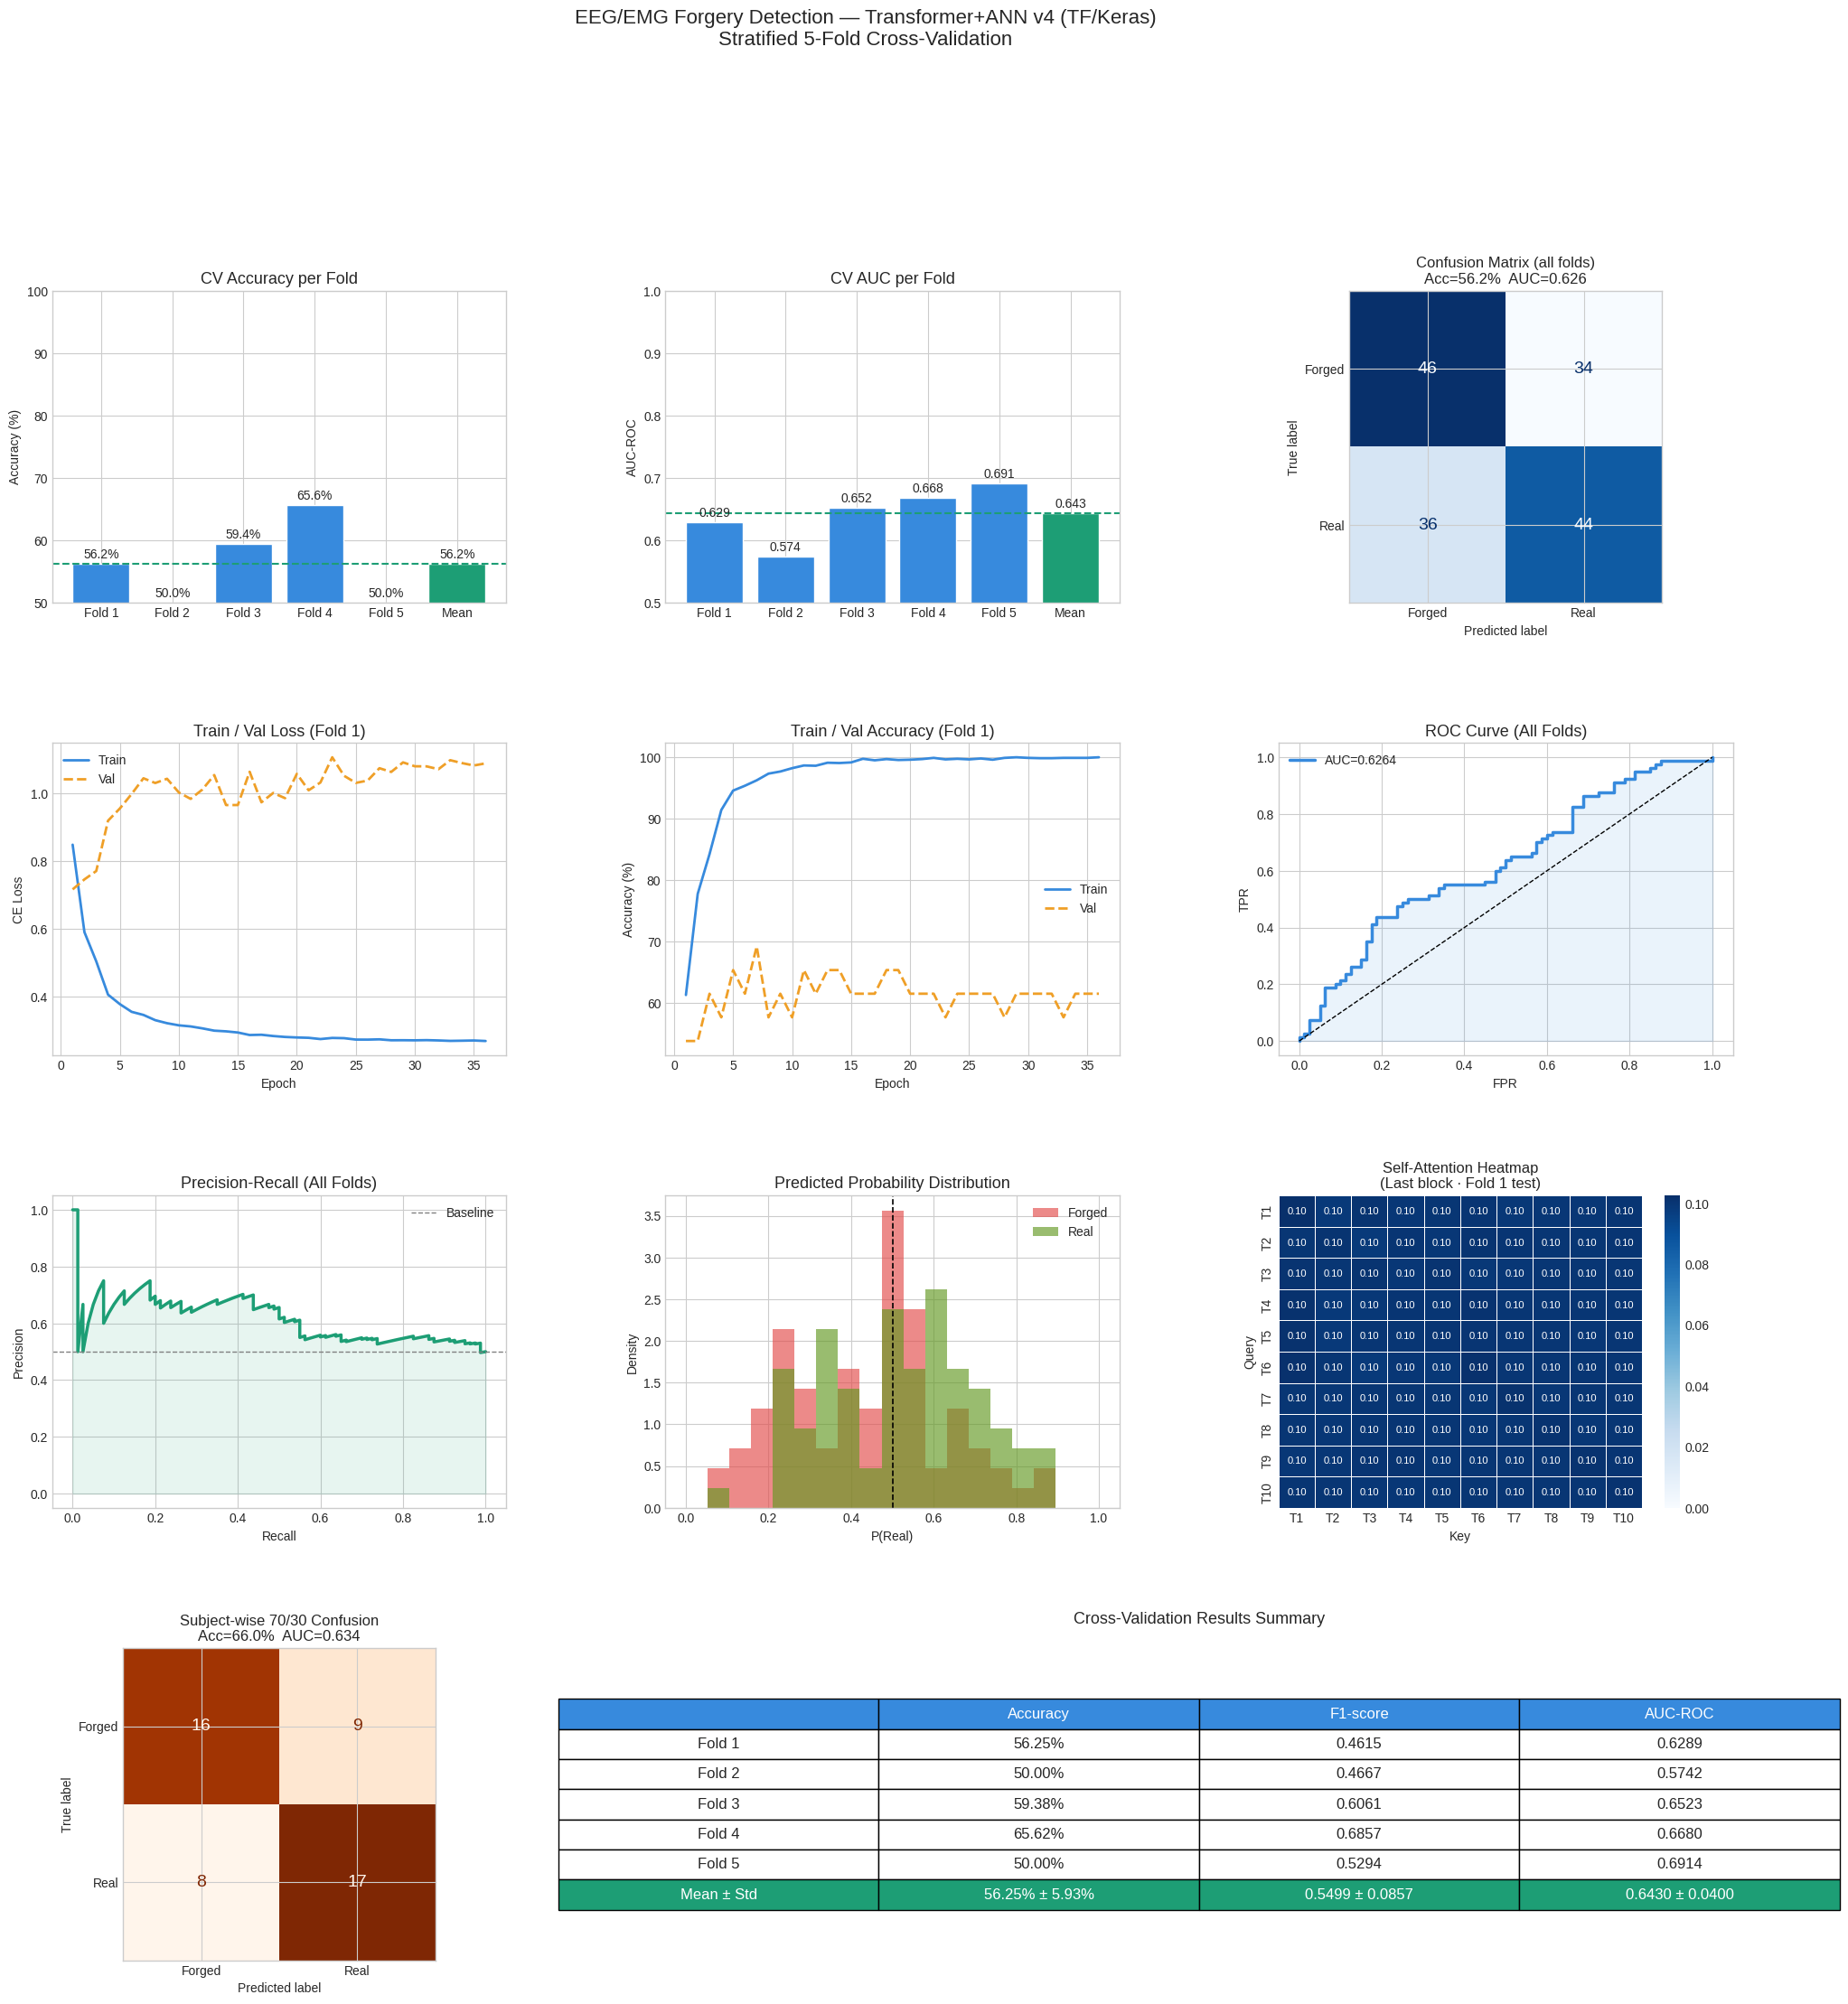

Figure saved → transformer_ann_v4_results.png

Model saved  → transformer_ann_v4_fold0.keras
Artefacts    → fold_artefacts_v4.pkl

Done.


In [21]:
# =============================================================================
# 13.  PLOTS  (11-panel figure)
# =============================================================================
plt.style.use("seaborn-v0_8-whitegrid")
PAL = {"train": "#378ADD", "val": "#EF9F27",
       "forged": "#E24B4A", "real": "#639922"}
 
fig = plt.figure(figsize=(24, 24))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)
 
# ── 13.1  CV accuracy per fold bar chart ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
fold_labels = [f"Fold {i+1}" for i in range(N_FOLDS)] + ["Mean"]
fold_vals   = [a*100 for a in accs] + [np.mean(accs)*100]
colors      = [PAL["train"]]*N_FOLDS + ["#1D9E75"]
bars        = ax1.bar(fold_labels, fold_vals, color=colors, edgecolor="white")
ax1.axhline(np.mean(accs)*100, linestyle="--", color="#1D9E75", lw=1.5)
ax1.set_ylim([50, 100])
ax1.set_ylabel("Accuracy (%)"); ax1.set_title("CV Accuracy per Fold", fontsize=13)
for bar, v in zip(bars, fold_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f"{v:.1f}%", ha="center", va="bottom", fontsize=10)
 
# ── 13.2  CV AUC per fold ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
auc_vals = aucs + [np.mean(aucs)]
bars2    = ax2.bar(fold_labels, auc_vals, color=colors, edgecolor="white")
ax2.axhline(np.mean(aucs), linestyle="--", color="#1D9E75", lw=1.5)
ax2.set_ylim([0.5, 1.0])
ax2.set_ylabel("AUC-ROC"); ax2.set_title("CV AUC per Fold", fontsize=13)
for bar, v in zip(bars2, auc_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f"{v:.3f}", ha="center", va="bottom", fontsize=10)
 
# ── 13.3  Confusion matrix (concatenated all folds) ───────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
disp = ConfusionMatrixDisplay(cm_all, display_labels=["Forged", "Real"])
disp.plot(ax=ax3, colorbar=False, cmap="Blues")
ax3.set_title(f"Confusion Matrix (all folds)\nAcc={acc_all*100:.1f}%  AUC={auc_all:.3f}",
              fontsize=12)
for t in disp.text_.ravel():
    t.set_fontsize(14)
 
# ── 13.4  Train/val loss (fold 0) ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
h0  = all_histories[0]
ep  = range(1, len(h0["loss"])+1)
ax4.plot(ep, h0["loss"],     color=PAL["train"], lw=2, label="Train")
ax4.plot(ep, h0["val_loss"], color=PAL["val"],   lw=2, linestyle="--", label="Val")
ax4.set_title("Train / Val Loss (Fold 1)", fontsize=13)
ax4.set_xlabel("Epoch"); ax4.set_ylabel("CE Loss"); ax4.legend()
 
# ── 13.5  Train/val accuracy (fold 0) ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(ep, [v*100 for v in h0["accuracy"]],
         color=PAL["train"], lw=2, label="Train")
ax5.plot(ep, [v*100 for v in h0["val_accuracy"]],
         color=PAL["val"],   lw=2, linestyle="--", label="Val")
ax5.set_title("Train / Val Accuracy (Fold 1)", fontsize=13)
ax5.set_xlabel("Epoch"); ax5.set_ylabel("Accuracy (%)"); ax5.legend()
 
# ── 13.6  ROC curve (all folds concatenated) ──────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
ax6.plot(fpr, tpr, color=PAL["train"], lw=2.5, label=f"AUC={auc_all:.4f}")
ax6.plot([0,1],[0,1], "k--", lw=1)
ax6.fill_between(fpr, tpr, alpha=0.10, color=PAL["train"])
ax6.set_title("ROC Curve (All Folds)", fontsize=13)
ax6.set_xlabel("FPR"); ax6.set_ylabel("TPR"); ax6.legend()
 
# ── 13.7  Precision-recall ────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
prec, rec, _ = precision_recall_curve(y_true_all, y_prob_all)
ax7.plot(rec, prec, color="#1D9E75", lw=2.5)
ax7.fill_between(rec, prec, alpha=0.10, color="#1D9E75")
ax7.axhline(0.5, linestyle="--", color="gray", lw=1, label="Baseline")
ax7.set_title("Precision-Recall (All Folds)", fontsize=13)
ax7.set_xlabel("Recall"); ax7.set_ylabel("Precision"); ax7.legend()
 
# ── 13.8  Probability distribution ───────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
bins = np.linspace(0, 1, 20)
ax8.hist(y_prob_all[y_true_all==0], bins=bins, alpha=0.65,
         color=PAL["forged"], label="Forged", density=True)
ax8.hist(y_prob_all[y_true_all==1], bins=bins, alpha=0.65,
         color=PAL["real"], label="Real", density=True)
ax8.axvline(0.5, linestyle="--", color="black", lw=1.2)
ax8.set_title("Predicted Probability Distribution", fontsize=13)
ax8.set_xlabel("P(Real)"); ax8.set_ylabel("Density"); ax8.legend()
 
# ── 13.9  Attention heatmap ───────────────────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
tok_labels = [f"T{i+1}" for i in range(SEQ_LEN)]
sns.heatmap(attn_map, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=tok_labels, yticklabels=tok_labels,
            ax=ax9, linewidths=0.4, cbar=True, vmin=0, annot_kws={"size":8})
ax9.set_title("Self-Attention Heatmap\n(Last block · Fold 1 test)", fontsize=12)
ax9.set_xlabel("Key"); ax9.set_ylabel("Query")
 
# ── 13.10  Subject-wise 70/30 confusion matrix ───────────────────────────────
ax10 = fig.add_subplot(gs[3, 0])
disp2 = ConfusionMatrixDisplay(sw_cm, display_labels=["Forged","Real"])
disp2.plot(ax=ax10, colorbar=False, cmap="Oranges")
ax10.set_title(f"Subject-wise 70/30 Confusion\nAcc={sw_acc*100:.1f}%  AUC={sw_auc:.3f}",
               fontsize=12)
for t in disp2.text_.ravel():
    t.set_fontsize(14)
 
# ── 13.11  Per-fold metrics table ─────────────────────────────────────────────
ax11 = fig.add_subplot(gs[3, 1:])
ax11.axis("off")
table_data = [[f"Fold {m['fold']}", f"{m['acc']*100:.2f}%",
               f"{m['f1']:.4f}", f"{m['auc']:.4f}"]
              for m in fold_metrics]
table_data.append(["Mean ± Std",
                   f"{np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%",
                   f"{np.mean(f1s):.4f} ± {np.std(f1s):.4f}",
                   f"{np.mean(aucs):.4f} ± {np.std(aucs):.4f}"])
tbl = ax11.table(
    cellText=table_data,
    colLabels=["", "Accuracy", "F1-score", "AUC-ROC"],
    cellLoc="center", loc="center",
)
tbl.auto_set_font_size(False); tbl.set_fontsize(12); tbl.scale(1.2, 2.0)
for (r, c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor("#378ADD"); cell.set_text_props(color="white")
    elif r == len(table_data): cell.set_facecolor("#1D9E75"); cell.set_text_props(color="white")
ax11.set_title("Cross-Validation Results Summary", fontsize=13, pad=20)
 
plt.suptitle(
    "EEG/EMG Forgery Detection — Transformer+ANN v4 (TF/Keras)\n"
    "Stratified 5-Fold Cross-Validation",
    fontsize=16, y=1.01,
)
plt.savefig("transformer_ann_v4_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → transformer_ann_v4_results.png")
 
# =============================================================================
# 14.  SAVE ARTEFACTS
# =============================================================================
fold_models[0].save("transformer_ann_v4_fold0.keras")
with open("fold_artefacts_v4.pkl", "wb") as fh:
    pickle.dump(fold_artefacts, fh)
 
print("\nModel saved  → transformer_ann_v4_fold0.keras")
print("Artefacts    → fold_artefacts_v4.pkl")
print("\nDone.")
 